# Leakage-Aware Multi-Class Classification of Mental-Health Conditions from Social Media Text

**CSE440: Natural Language Processing II — Lab Project**



---
# 0. Environment setup

Install packages not present by default in Colab. `datasketch` provides the MinHash/LSH index used for near-duplicate detection.

In [ ]:
!pip install -q datasketch gensim wordcloud kagglehub 2>/dev/null
print("installs complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.2/107.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 48.6 MB/s eta 0:00:00
installs complete


Core imports and display settings.

In [ ]:
import os, re, json, time, random, warnings, string, itertools
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

print("pandas", pd.__version__)
print("numpy ", np.__version__)

pandas 2.2.2
numpy  2.0.2


A single seed function called at the top of every experiment, so runs are reproducible.

In [ ]:
SEED = 42

def set_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except Exception:
        pass
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    except Exception:
        pass

set_seeds()
print("seeds set to", SEED)

seeds set to 42


## 0.1 Configuration

Every switch that controls cost lives here. `FAST_MODE` is the master toggle.

In [ ]:
FAST_MODE = True

CONFIG = {
    "sample_n":      8000 if FAST_MODE else None,
    "rnn_epochs":    4    if FAST_MODE else 15,
    "rnn_patience":  2,
    "bert_epochs":   1    if FAST_MODE else 3,
    "bert_max_len":  128,
    "bert_batch":    32,
    "max_len":       128,
    "vocab_size":    20000,
    "tfidf_features": 10000,
    "glove_dim":     100 if FAST_MODE else 300,
    "w2v_dim":       100,
    "run_bert":      True,
    "run_split_b":   True,
    "near_dup_threshold": 0.8,
    "random_state":  SEED,
}

OUT = Path("outputs")
for sub in ["figures", "predictions", "models", "tables"]:
    (OUT / sub).mkdir(parents=True, exist_ok=True)

print(json.dumps(CONFIG, indent=2))
print("\nFAST_MODE =", FAST_MODE, "-> set to False for the final full run")

{
  "sample_n": 8000,
  "rnn_epochs": 4,
  "rnn_patience": 2,
  "bert_epochs": 1,
  "bert_max_len": 128,
  "bert_batch": 32,
  "max_len": 128,
  "vocab_size": 20000,
  "tfidf_features": 10000,
  "glove_dim": 100,
  "w2v_dim": 100,
  "run_bert": true,
  "run_split_b": true,
  "near_dup_threshold": 0.8,
  "random_state": 42
}

FAST_MODE = True -> set to False for the final full run


Check for GPU. The recurrent models and BERT are far slower on CPU; if no GPU is present, consider setting `run_bert` to `False`.

In [ ]:
GPU_AVAILABLE = False
try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
    print("torch:", torch.__version__, "| CUDA:", GPU_AVAILABLE)
    if GPU_AVAILABLE:
        print("device:", torch.cuda.get_device_name(0))
except Exception as e:
    print("torch unavailable:", e)

if not GPU_AVAILABLE:
    print("\nWARNING: no GPU detected. Runtime -> Change runtime type -> T4 GPU")

torch: 2.11.0+cu128 | CUDA: True
device: Tesla T4


---
# 1. Data loading

The notebook tries three routes in order: an already-present local file, `kagglehub`, then manual upload. Any one of them is sufficient.

In [ ]:
DATA_PATH = None
CANDIDATES = ["Combined Data.csv", "data.csv", "combined_data.csv"]

for c in CANDIDATES:
    if Path(c).exists():
        DATA_PATH = c
        print("found local file:", c)
        break

if DATA_PATH is None:
    try:
        import kagglehub
        p = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")
        for f in Path(p).rglob("*.csv"):
            DATA_PATH = str(f)
            print("downloaded via kagglehub:", DATA_PATH)
            break
    except Exception as e:
        print("kagglehub route failed:", type(e).__name__, e)

if DATA_PATH is None:
    print("\nManual route: download 'Combined Data.csv' from")
    print("https://www.kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health")
    print("then run the next cell to upload it.")
else:
    print("\nDATA_PATH =", DATA_PATH)

Using Colab cache for faster access to the 'sentiment-analysis-for-mental-health' dataset.
downloaded via kagglehub: /kaggle/input/sentiment-analysis-for-mental-health/Combined Data.csv

DATA_PATH = /kaggle/input/sentiment-analysis-for-mental-health/Combined Data.csv


Run this cell **only if** the automatic routes above failed.

In [ ]:
if DATA_PATH is None:
    try:
        from google.colab import files
        up = files.upload()
        DATA_PATH = list(up.keys())[0]
        print("uploaded:", DATA_PATH)
    except Exception as e:
        raise SystemExit("Could not obtain the dataset. Place the CSV next to this notebook. " + str(e))
else:
    print("skipped, DATA_PATH already set:", DATA_PATH)

skipped, DATA_PATH already set: /kaggle/input/sentiment-analysis-for-mental-health/Combined Data.csv


Load and normalise column names. The raw file has an unnamed index column, a `statement` column and a `status` column.

In [ ]:
raw = pd.read_csv(DATA_PATH)
print("raw shape:", raw.shape)
print("columns:", list(raw.columns))

raw = raw.loc[:, ~raw.columns.str.contains("^Unnamed")]
rename_map = {}
for c in raw.columns:
    lc = c.strip().lower()
    if lc in ("statement", "text", "post", "content"):
        rename_map[c] = "text"
    elif lc in ("status", "label", "class", "target"):
        rename_map[c] = "label"
raw = raw.rename(columns=rename_map)

assert "text" in raw.columns and "label" in raw.columns, f"unexpected columns: {list(raw.columns)}"
raw = raw[["text", "label"]]
raw.head(5)

raw shape: (53043, 3)
columns: ['Unnamed: 0', 'statement', 'status']


,text,label
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless heart. All out of tune",Anxiety
2,"All wrong, back off dear, forward doubt. Stay in a restless and restless place",Anxiety
3,I've shifted my focus to something else but I'm still worried,Anxiety
4,"I'm restless and restless, it's been a month now, boy. What do you mean?",Anxiety


---
# 2. Exploratory Data Analysis

Standard EDA first (spec §3.3), then the five diagnostics that motivate the leakage analysis.

## 2.1 Missing values and basic integrity

In [ ]:
print("rows:", len(raw))
print("\nmissing values per column:")
print(raw.isna().sum())

empty_text = raw["text"].isna() | (raw["text"].astype(str).str.strip() == "")
print("\nempty or whitespace-only statements:", int(empty_text.sum()))

df = raw[~empty_text].copy()
df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(str).str.strip()
print("rows after dropping empty statements:", len(df))

rows: 53043

missing values per column:
text     362
label      0
dtype: int64

empty or whitespace-only statements: 362
rows after dropping empty statements: 52681


## 2.2 Class distribution

In [ ]:
dist = df["label"].value_counts()
dist_pct = (dist / len(df) * 100).round(2)
class_table = pd.DataFrame({"count": dist, "percent": dist_pct})
CLASSES = list(dist.index)

print(class_table.to_string())
print("\nnumber of classes:", len(CLASSES))
print("imbalance ratio (largest : smallest): %.1f : 1" % (dist.max() / dist.min()))
print("majority-class baseline accuracy: %.4f" % (dist.max() / len(df)))

MAJORITY_BASELINE = dist.max() / len(df)

                      count  percent
label                               
Normal                16343    31.02
Depression            15404    29.24
Suicidal              10652    20.22
Anxiety                3841     7.29
Bipolar                2777     5.27
Stress                 2587     4.91
Personality disorder   1077     2.04

number of classes: 7
imbalance ratio (largest : smallest): 15.2 : 1
majority-class baseline accuracy: 0.3102


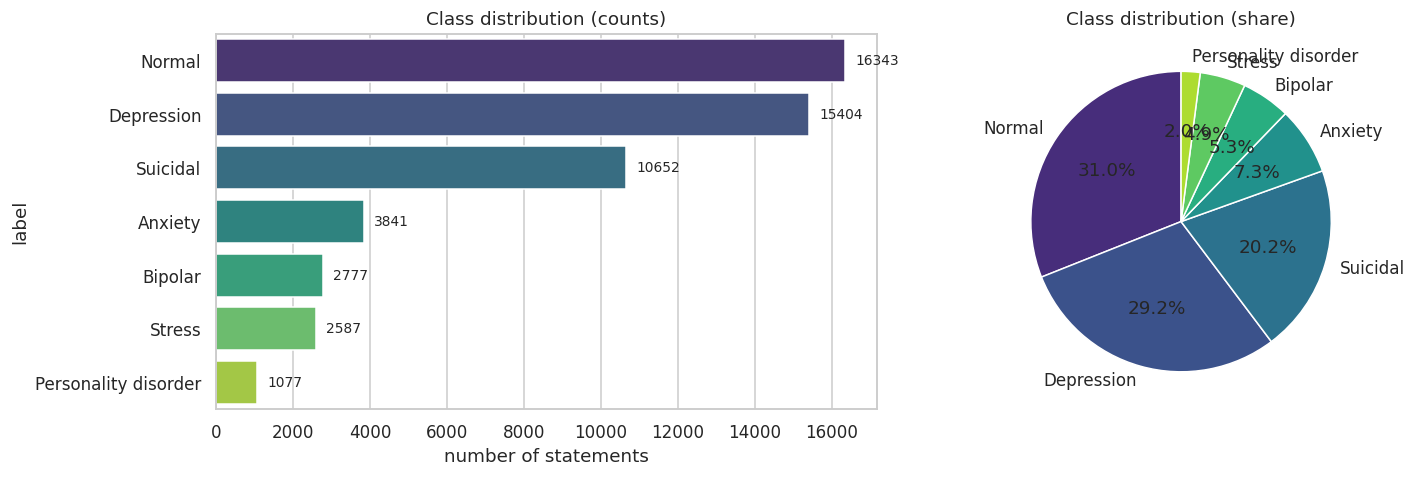

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(x=dist.values, y=dist.index, ax=ax[0], palette="viridis")
ax[0].set_title("Class distribution (counts)")
ax[0].set_xlabel("number of statements")
for i, v in enumerate(dist.values):
    ax[0].text(v + len(df) * 0.005, i, str(v), va="center", fontsize=9)

ax[1].pie(dist.values, labels=dist.index, autopct="%1.1f%%", startangle=90,
          colors=sns.color_palette("viridis", len(dist)))
ax[1].set_title("Class distribution (share)")
plt.tight_layout()
plt.savefig(OUT / "figures" / "class_distribution.png", bbox_inches="tight")
plt.show()

## 2.3 Text length statistics

Length matters here for a specific reason. The corpus is an amalgamation of separate source datasets — conversational chatbot logs, long-form Reddit posts, and tweets — and each source contributed predominantly to certain classes. If length distributions differ sharply by class, length is a proxy for source, and therefore a shortcut for label.

In [ ]:
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()
df["mean_word_len"] = df["char_count"] / df["word_count"].replace(0, np.nan)
df["mean_word_len"] = df["mean_word_len"].fillna(0)

len_stats = df.groupby("label")[["char_count", "word_count", "mean_word_len"]].agg(["mean", "median", "std"]).round(1)
print(len_stats.to_string())

                     char_count                word_count               mean_word_len             
                           mean median     std       mean median    std          mean median   std
label                                                                                             
Anxiety                   764.7  544.0   812.4      143.8  102.0  152.6           5.4    5.3   0.6
Bipolar                   946.1  699.0   952.5      176.2  129.0  176.5           5.4    5.3   0.5
Depression                844.0  562.0   953.0      168.0  113.0  188.2           5.1    5.0   2.4
Normal                     90.2   50.0   120.9       17.2   10.0   22.8           5.3    5.1   1.6
Personality disorder      956.7  736.0  1149.8      179.3  137.0  221.9           5.5    5.3   1.0
Stress                    613.5  459.0   570.1      114.6   87.0  105.9           5.6    5.2   2.0
Suicidal                  735.0  453.0   982.2      146.4   92.0  187.0           5.3    4.9  30.6


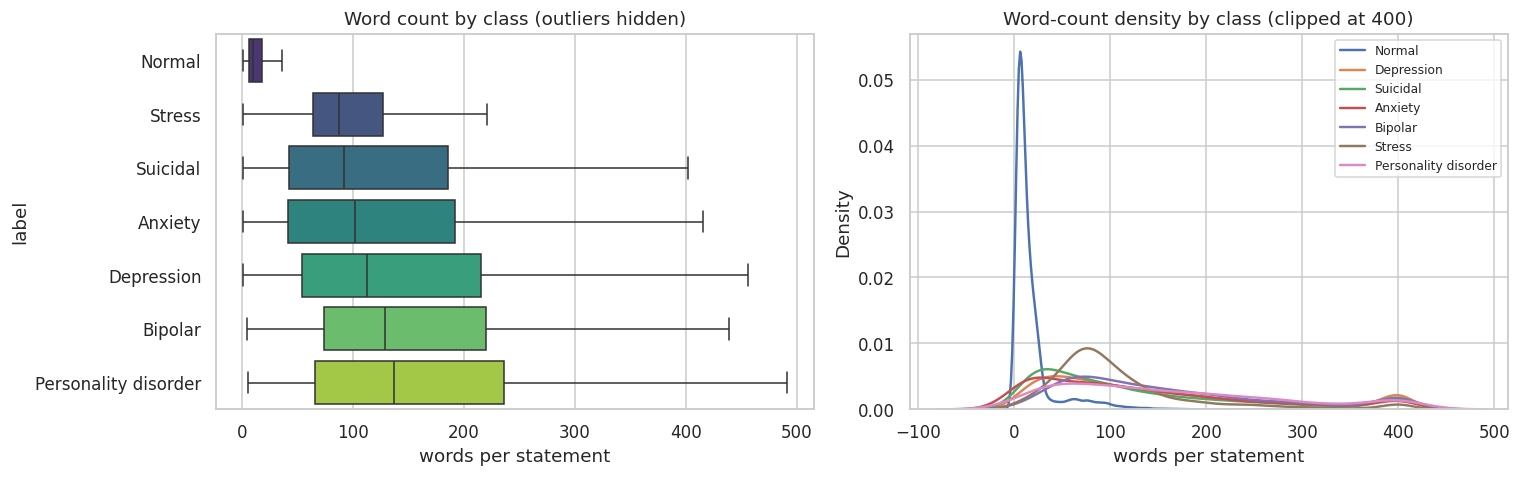

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
order = df.groupby("label")["word_count"].median().sort_values().index
sns.boxplot(data=df, x="word_count", y="label", order=order, ax=ax[0], showfliers=False, palette="viridis")
ax[0].set_title("Word count by class (outliers hidden)")
ax[0].set_xlabel("words per statement")

for c in CLASSES:
    sub = df.loc[df.label == c, "word_count"].clip(upper=400)
    sns.kdeplot(sub, ax=ax[1], label=c, fill=False, linewidth=1.6)
ax[1].set_title("Word-count density by class (clipped at 400)")
ax[1].set_xlabel("words per statement")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / "figures" / "length_by_class.png", bbox_inches="tight")
plt.show()

## 2.4 Word clouds per class

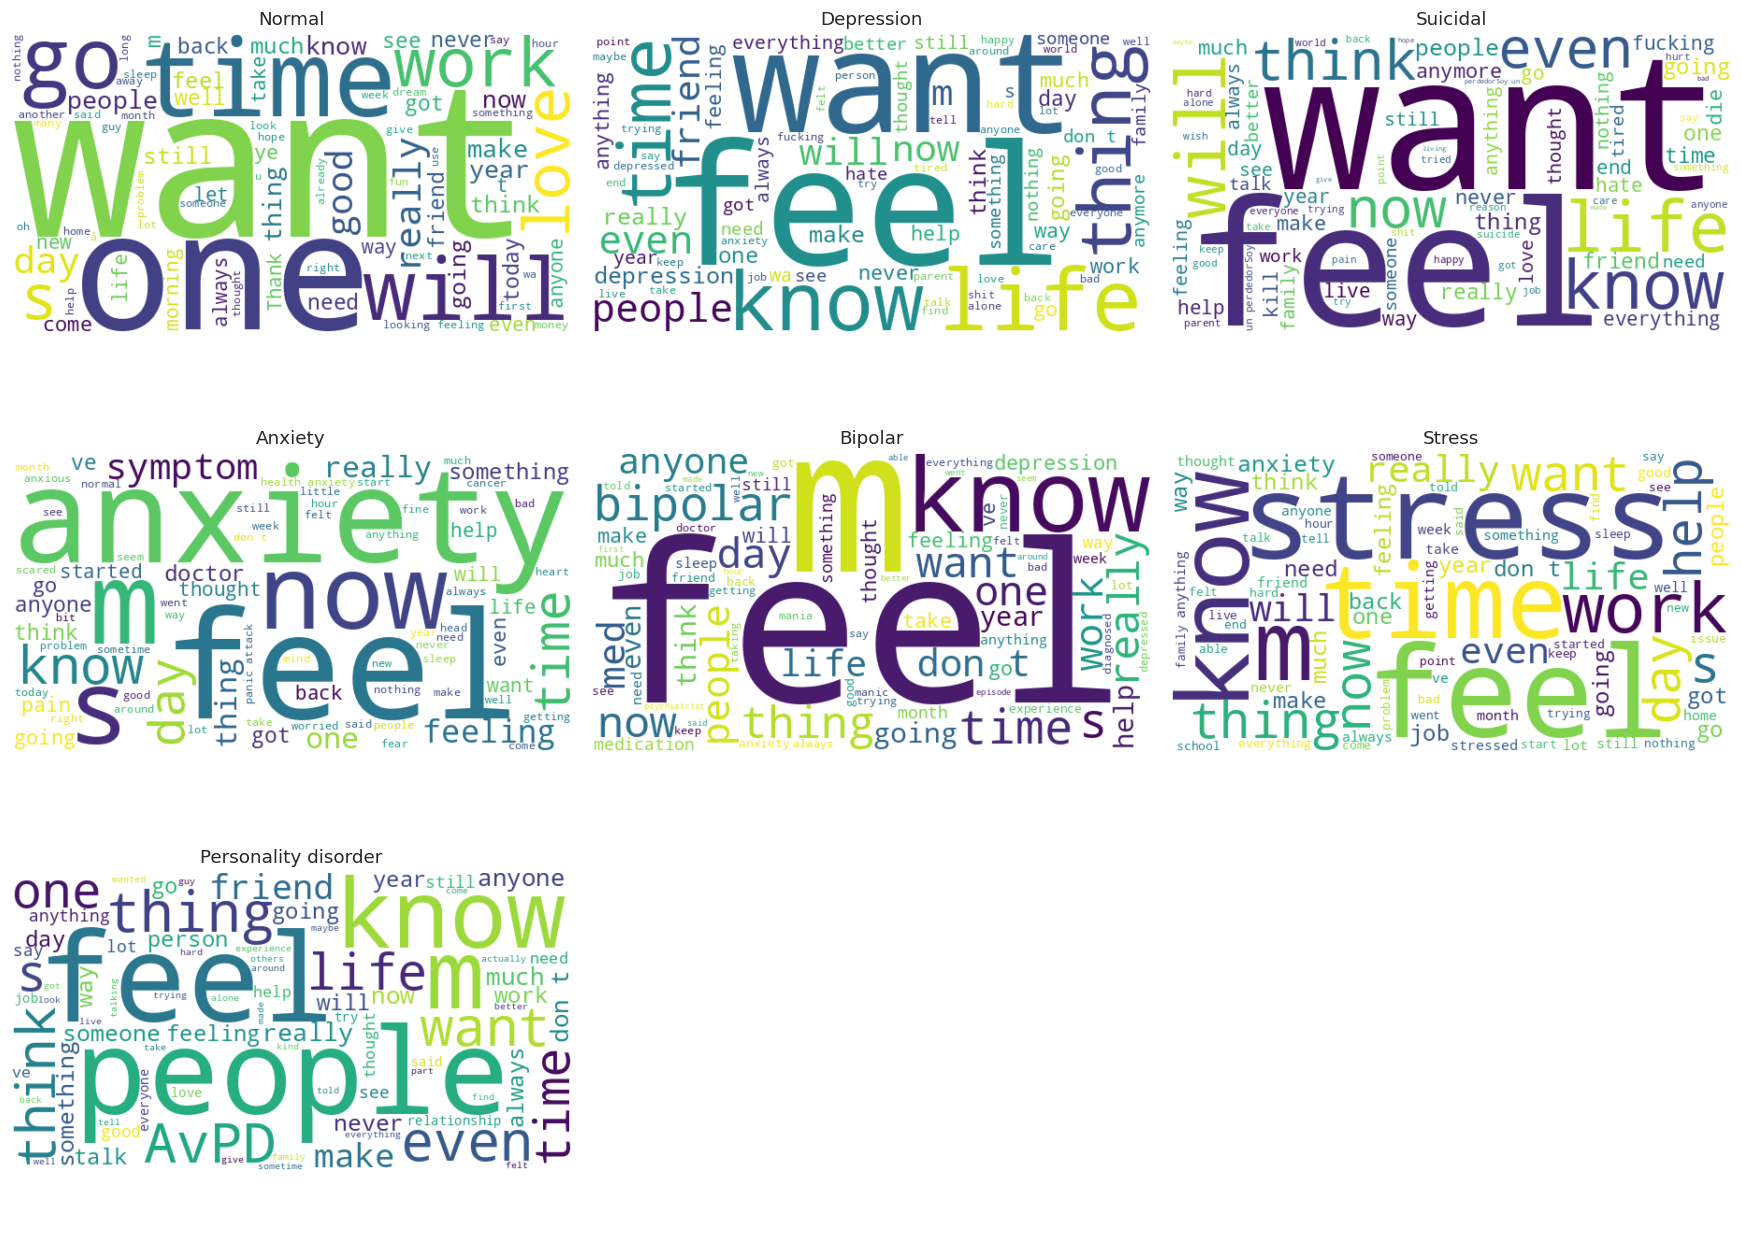

In [ ]:
from wordcloud import WordCloud, STOPWORDS

sw = set(STOPWORDS)
n_cls = len(CLASSES)
rows = int(np.ceil(n_cls / 3))
fig, axes = plt.subplots(rows, 3, figsize=(16, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, c in enumerate(CLASSES):
    joined = " ".join(df.loc[df.label == c, "text"].sample(min(1500, (df.label == c).sum()), random_state=SEED))
    wc = WordCloud(width=600, height=320, background_color="white",
                   stopwords=sw, colormap="viridis", max_words=80).generate(joined)
    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(c, fontsize=12)
    axes[i].axis("off")

for j in range(n_cls, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(OUT / "figures" / "wordclouds.png", bbox_inches="tight")
plt.show()

---
## 2.5 Diagnostic D1 — Exact duplicates

Prior work on this benchmark does not report deduplication. We measure three quantities:

- exact duplicate statements after whitespace/case normalisation,
- how many distinct statements are affected,
- **cross-label duplicates**: identical text carrying two different labels. These place a hard ceiling on achievable accuracy, because no model can be right on both copies.

In [ ]:
def norm_key(s):
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

df["norm_key"] = df["text"].map(norm_key)

n_total = len(df)
n_unique = df["norm_key"].nunique()
n_dup_rows = n_total - n_unique

grp = df.groupby("norm_key")["label"].nunique()
conflicting_keys = set(grp[grp > 1].index)
n_conflict_rows = int(df["norm_key"].isin(conflicting_keys).sum())

print("total rows                       :", n_total)
print("unique normalised statements     :", n_unique)
print("exact duplicate rows             :", n_dup_rows, f"({n_dup_rows/n_total*100:.2f}%)")
print("statements with >1 distinct label:", len(conflicting_keys))
print("rows involved in label conflicts :", n_conflict_rows, f"({n_conflict_rows/n_total*100:.2f}%)")

D1 = {"total": n_total, "unique": n_unique, "dup_rows": n_dup_rows,
      "conflicting_keys": len(conflicting_keys), "conflict_rows": n_conflict_rows}

total rows                       : 52681
unique normalised statements     : 51044
exact duplicate rows             : 1637 (3.11%)
statements with >1 distinct label: 22
rows involved in label conflicts : 62 (0.12%)


Inspect a few conflicting cases. These are genuinely ambiguous items, not preprocessing artifacts.

In [ ]:
if conflicting_keys:
    sample_keys = list(conflicting_keys)[:3]
    for k in sample_keys:
        sub = df[df["norm_key"] == k]
        print("-" * 90)
        print("TEXT:", sub["text"].iloc[0][:220])
        print("LABELS:", sub["label"].value_counts().to_dict())
else:
    print("no cross-label duplicates found")

------------------------------------------------------------------------------------------
TEXT: Unable to overcome extreme stress severely impacting my productivity I am seriously regretting my decision to go to grad school- I thought I was prepared for it, but I'm wasn't. I was an academically strong student in my
LABELS: {'Depression': 1, 'Anxiety': 1}
------------------------------------------------------------------------------------------
TEXT: we are able to fly space ships and control satellites out into earths orbit.Figure out how to do quantum physics and create computers.Understand the atomic level and the large planetary bodies.But we do not know how to f
LABELS: {'Suicidal': 1, 'Depression': 1}
------------------------------------------------------------------------------------------
TEXT: Hi,I am a 28 year old (she will of a) man from the UK suffering with **severe** depression and most likely an undiagnosed mental illness!I entered such a dark corner of my mind that I tr

---
## 2.6 Diagnostic D2 — Near-duplicates

Exact matching misses reposts, crossposts and lightly-edited variants. We build a MinHash/LSH index over 5-gram character shingles and join any pair with estimated Jaccard similarity above the threshold. Connected components of that graph become **groups**, which the group-aware split (§4) keeps intact.

In [ ]:
from datasketch import MinHash, MinHashLSH

def shingles(s, k=5):
    s = re.sub(r"\s+", " ", s.lower().strip())
    if len(s) <= k:
        return {s} if s else set()
    return {s[i:i+k] for i in range(len(s) - k + 1)}

class UnionFind:
    def __init__(self, n):
        self.p = list(range(n))
    def find(self, x):
        while self.p[x] != x:
            self.p[x] = self.p[self.p[x]]
            x = self.p[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.p[rb] = ra

t0 = time.time()
texts = df["text"].tolist()
lsh = MinHashLSH(threshold=CONFIG["near_dup_threshold"], num_perm=64)
minhashes = []

for i, t in enumerate(texts):
    m = MinHash(num_perm=64)
    for sh in shingles(t):
        m.update(sh.encode("utf8"))
    minhashes.append(m)
    lsh.insert(str(i), m)

uf = UnionFind(len(texts))
n_pairs = 0
for i, m in enumerate(minhashes):
    for j in lsh.query(m):
        j = int(j)
        if j != i:
            uf.union(i, j)
            n_pairs += 1

group_ids = np.array([uf.find(i) for i in range(len(texts))])
df["group"] = group_ids

gs = pd.Series(group_ids).value_counts()
print("MinHash/LSH completed in %.1fs" % (time.time() - t0))
print("candidate near-duplicate links :", n_pairs)
print("distinct groups                :", len(gs))
print("rows in multi-member groups    :", int(gs[gs > 1].sum()), f"({gs[gs>1].sum()/len(df)*100:.2f}%)")
print("largest group size             :", int(gs.max()))

D2 = {"groups": int(len(gs)), "rows_in_multi_groups": int(gs[gs > 1].sum()), "largest_group": int(gs.max())}

MinHash/LSH completed in 487.6s
candidate near-duplicate links : 5988
distinct groups                : 50733
rows in multi-member groups    : 3590 (6.81%)
largest group size             : 22


---
## 2.7 Diagnostic D3 — The no-text baseline

**This is the central diagnostic of the project.**

We fit a Logistic Regression using exactly three numeric features: character count, word count, and mean word length. There is no vocabulary, no token, no text of any kind. A model with no access to language should not be able to identify a mental-health condition.

If this baseline scores materially above the majority-class rate, then post length alone carries substantial label information — which follows directly from the corpus being nine separately-sourced datasets stitched together.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import accuracy_score, f1_score, classification_report

set_seeds()
Xn = df[["char_count", "word_count", "mean_word_len"]].values
yn = df["label"].values
Xtr, Xte, ytr, yte = tts(Xn, yn, test_size=0.2, stratify=yn, random_state=SEED)

notext = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1500, class_weight="balanced"))
notext.fit(Xtr, ytr)
pred_nt = notext.predict(Xte)

NOTEXT_ACC = accuracy_score(yte, pred_nt)
NOTEXT_F1 = f1_score(yte, pred_nt, average="macro")

print("majority-class baseline accuracy : %.4f" % MAJORITY_BASELINE)
print("NO-TEXT baseline accuracy        : %.4f" % NOTEXT_ACC)
print("NO-TEXT baseline macro-F1        : %.4f" % NOTEXT_F1)
print("absolute lift over majority      : %+.4f" % (NOTEXT_ACC - MAJORITY_BASELINE))
print()
print(classification_report(yte, pred_nt, digits=3, zero_division=0))

majority-class baseline accuracy : 0.3102
NO-TEXT baseline accuracy        : 0.4579
NO-TEXT baseline macro-F1        : 0.2932
absolute lift over majority      : +0.1477

                      precision    recall  f1-score   support

             Anxiety      0.158     0.044     0.069       768
             Bipolar      0.233     0.257     0.244       556
          Depression      0.521     0.187     0.275      3081
              Normal      0.691     0.903     0.783      3269
Personality disorder      0.060     0.107     0.077       215
              Stress      0.154     0.429     0.227       517
            Suicidal      0.349     0.411     0.378      2131

            accuracy                          0.458     10537
           macro avg      0.309     0.334     0.293     10537
        weighted avg      0.470     0.458     0.430     10537



---
## 2.8 Diagnostic D5 — Class language overlap

Jensen–Shannon divergence between per-class unigram distributions. Low divergence between two classes predicts that models will confuse them. We check this against the actual confusion matrices in §10, which grounds the results discussion in the EDA as spec §3.9 requires.

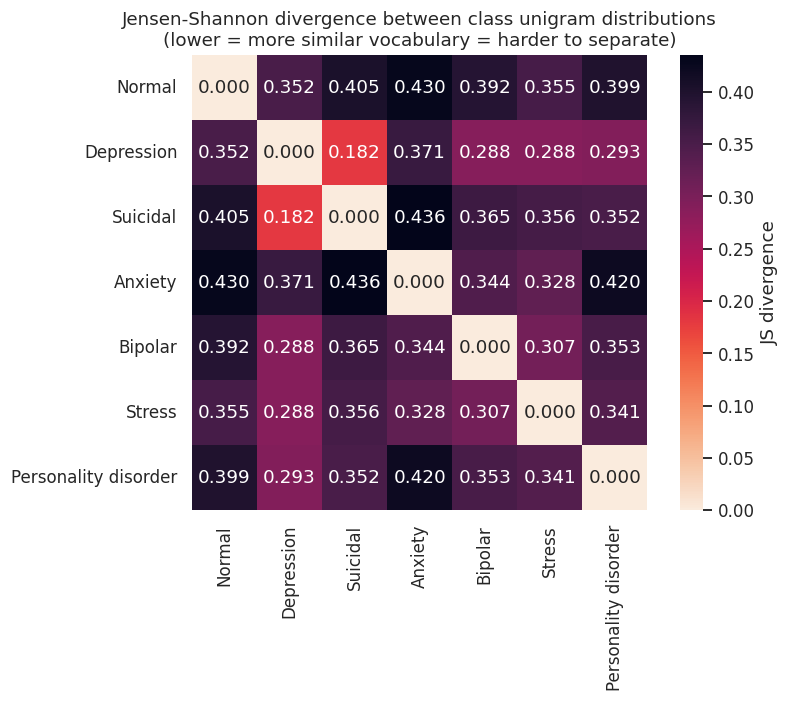

most similar class pairs (predicted confusions):
  Depression             <-> Suicidal                JSD = 0.1817
  Depression             <-> Stress                  JSD = 0.2880
  Depression             <-> Bipolar                 JSD = 0.2885
  Depression             <-> Personality disorder    JSD = 0.2926
  Bipolar                <-> Stress                  JSD = 0.3074


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from scipy.spatial.distance import jensenshannon

cv = CountVectorizer(max_features=5000, stop_words="english", min_df=3)
per_class_docs = [" ".join(df.loc[df.label == c, "text"].astype(str)) for c in CLASSES]
Xc = cv.fit_transform(per_class_docs).toarray().astype(float)
P = Xc / Xc.sum(axis=1, keepdims=True)

JSD = np.zeros((len(CLASSES), len(CLASSES)))
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        JSD[i, j] = jensenshannon(P[i], P[j], base=2)

jsd_df = pd.DataFrame(JSD, index=CLASSES, columns=CLASSES)

plt.figure(figsize=(8, 6.5))
sns.heatmap(jsd_df, annot=True, fmt=".3f", cmap="rocket_r", square=True, cbar_kws={"label": "JS divergence"})
plt.title("Jensen-Shannon divergence between class unigram distributions\n(lower = more similar vocabulary = harder to separate)")
plt.tight_layout()
plt.savefig(OUT / "figures" / "jsd_heatmap.png", bbox_inches="tight")
plt.show()

iu = np.triu_indices(len(CLASSES), k=1)
pairs = sorted(zip(JSD[iu], [(CLASSES[a], CLASSES[b]) for a, b in zip(*iu)]))
print("most similar class pairs (predicted confusions):")
for v, (a, b) in pairs[:5]:
    print("  %-22s <-> %-22s  JSD = %.4f" % (a, b, v))

---
## 2.9 EDA summary

A consolidated figure combining the diagnostics. This is the single chart to lead with in the report and the presentation.

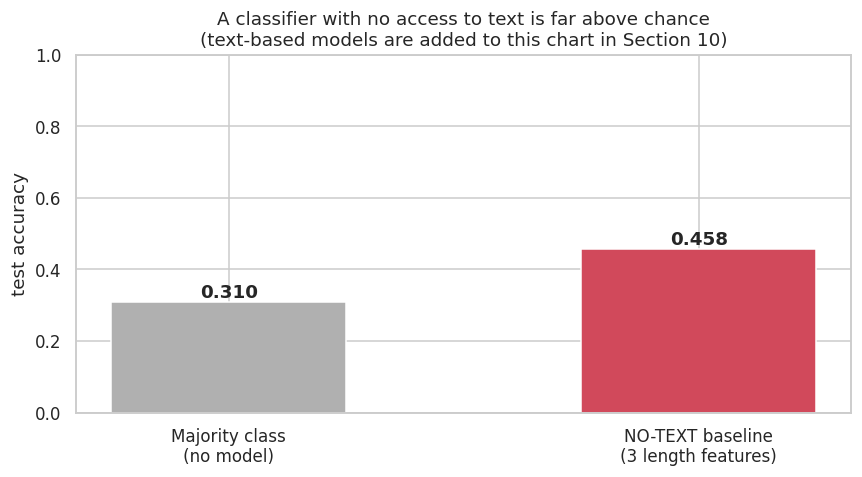

,value
rows,52681.000000
classes,7.000000
imbalance_ratio,15.174559
majority_baseline,0.310226
exact_dup_rows,1637.000000
cross_label_conflict_rows,62.000000
near_dup_rows,3590.000000
notext_accuracy,0.457910
notext_macro_f1,0.293208


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = {
    "Majority class\n(no model)": MAJORITY_BASELINE,
    "NO-TEXT baseline\n(3 length features)": NOTEXT_ACC,
}
cols = ["#b0b0b0", "#d1495b"]
b = ax.bar(list(bars.keys()), list(bars.values()), color=cols, width=0.5)
for r, v in zip(b, bars.values()):
    ax.text(r.get_x() + r.get_width() / 2, v + 0.012, f"{v:.3f}", ha="center", fontweight="bold")
ax.set_ylim(0, 1.0)
ax.set_ylabel("test accuracy")
ax.set_title("A classifier with no access to text is far above chance\n(text-based models are added to this chart in Section 10)")
plt.tight_layout()
plt.savefig(OUT / "figures" / "notext_baseline.png", bbox_inches="tight")
plt.show()

EDA_SUMMARY = {
    "rows": int(len(df)),
    "classes": int(len(CLASSES)),
    "imbalance_ratio": float(dist.max() / dist.min()),
    "majority_baseline": float(MAJORITY_BASELINE),
    "exact_dup_rows": int(D1["dup_rows"]),
    "cross_label_conflict_rows": int(D1["conflict_rows"]),
    "near_dup_rows": int(D2["rows_in_multi_groups"]),
    "notext_accuracy": float(NOTEXT_ACC),
    "notext_macro_f1": float(NOTEXT_F1),
}
pd.Series(EDA_SUMMARY).to_frame("value")

---
# 3. Data preprocessing

We do not pick one pipeline and justify it in prose. We build a ladder and measure it (spec §3.4).

| ID | Pipeline |
|---|---|
| `P0` | raw text, unchanged |
| `P1` | lowercase, strip URLs / HTML / handles / emails / digits |
| `P2` | P1 + punctuation removal + whitespace normalisation |
| `P3` | P2 + stopword removal |
| `P4` | P3 + WordNet lemmatisation |
| `P5` | P2 + negation-aware handling (`not happy` becomes `not_happy`) |

**An asymmetry we apply deliberately:** P3 and P4 suit sparse bag-of-words models, but they are harmful for BERT, whose WordPiece tokenizer and attention mechanism rely on punctuation, casing cues and function words. BERT therefore receives `P1` only.

In [ ]:
import nltk
for pkg in ["stopwords", "wordnet", "omw-1.4", "punkt", "averaged_perceptron_tagger"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem import WordNetLemmatizer

STOPWORDS_EN = set(nltk_stopwords.words("english"))
NEGATIONS = {"not", "no", "never", "none", "nothing", "nobody", "cannot", "cant", "wont", "dont", "isnt", "arent", "wasnt"}
KEEP = STOPWORDS_EN - NEGATIONS
LEMMATIZER = WordNetLemmatizer()

URL_RE = re.compile(r"https?://\S+|www\.\S+")
HTML_RE = re.compile(r"<.*?>")
HANDLE_RE = re.compile(r"[@#]\w+")
EMAIL_RE = re.compile(r"\S+@\S+")
DIGIT_RE = re.compile(r"\d+")
PUNCT_RE = re.compile(r"[%s]" % re.escape(string.punctuation))
WS_RE = re.compile(r"\s+")

print("stopwords loaded:", len(STOPWORDS_EN))

stopwords loaded: 198


Each pipeline stage is a small pure function so the ladder is auditable and reusable.

In [ ]:
def p0(t):
    return t

def p1(t):
    t = t.lower()
    t = URL_RE.sub(" ", t)
    t = HTML_RE.sub(" ", t)
    t = EMAIL_RE.sub(" ", t)
    t = HANDLE_RE.sub(" ", t)
    t = DIGIT_RE.sub(" ", t)
    return WS_RE.sub(" ", t).strip()

def p2(t):
    t = PUNCT_RE.sub(" ", p1(t))
    return WS_RE.sub(" ", t).strip()

def p3(t):
    return " ".join(w for w in p2(t).split() if w not in STOPWORDS_EN)

def p4(t):
    return " ".join(LEMMATIZER.lemmatize(w) for w in p3(t).split())

def p5(t):
    toks = p2(t).split()
    out, negate = [], False
    for w in toks:
        if w in NEGATIONS:
            negate = True
            continue
        out.append("not_" + w if negate else w)
        negate = False
    return " ".join(w for w in out if w.split("not_")[-1] not in KEEP)

PIPELINES = {"P0": p0, "P1": p1, "P2": p2, "P3": p3, "P4": p4, "P5": p5}

demo = "I've been SO anxious lately... can't sleep AT ALL, not happy about it. See https://x.co/abc @friend 123"
for name, fn in PIPELINES.items():
    print(f"{name}: {fn(demo)}")

P0: I've been SO anxious lately... can't sleep AT ALL, not happy about it. See https://x.co/abc @friend 123
P1: i've been so anxious lately... can't sleep at all, not happy about it. see
P2: i ve been so anxious lately can t sleep at all not happy about it see
P3: anxious lately sleep happy see
P4: anxious lately sleep happy see
P5: anxious lately sleep not_happy see


Apply every pipeline once and cache the columns. If `FAST_MODE` is on, the corpus is subsampled first, in a stratified and group-respecting way so the diagnostics above remain meaningful.

In [ ]:
set_seeds()

if CONFIG["sample_n"] is not None and CONFIG["sample_n"] < len(df):
    keep_groups = (df[["group", "label"]]
                   .drop_duplicates("group")
                   .groupby("label", group_keys=False)
                   .apply(lambda g: g.sample(min(len(g), max(50, int(CONFIG["sample_n"] * len(g) / len(df)))),
                                             random_state=SEED)))
    work = df[df["group"].isin(set(keep_groups["group"]))].copy()
    print(f"FAST_MODE subsample: {len(df)} -> {len(work)} rows (whole groups kept intact)")
else:
    work = df.copy()
    print("using full corpus:", len(work), "rows")

t0 = time.time()
for name, fn in PIPELINES.items():
    work[name] = work["text"].map(fn)
print("all pipelines applied in %.1fs" % (time.time() - t0))

work = work[work["P2"].str.strip().str.len() > 0].reset_index(drop=True)
print("rows after dropping statements empty post-cleaning:", len(work))
work[["text", "P1", "P2", "P4"]].head(3)

FAST_MODE subsample: 52681 -> 7987 rows (whole groups kept intact)
all pipelines applied in 7.6s
rows after dropping statements empty post-cleaning: 7984


,text,P1,P2,P4
0,Sometimes it's your own thoughts that make you anxious and afraid to close your eyes until you don't sleep,sometimes it's your own thoughts that make you anxious and afraid to close your eyes until you don't sleep,sometimes it s your own thoughts that make you anxious and afraid to close your eyes until you don t sleep,sometimes thought make anxious afraid close eye sleep
1,"restive = restless, restless","restive = restless, restless",restive restless restless,restive restless restless
2,it makes you feel restless,it makes you feel restless,it makes you feel restless,make feel restless


---
# 4. Train / validation / test splits

Two protocols. Every experiment runs under both, and the difference between them is the project's headline result.

**Split-A — leaderboard-comparable.** Naive stratified 70/15/15 on the raw rows, exactly what prior work did. Duplicates and near-duplicates are free to land on both sides.

**Split-B — honest.** Exact duplicates removed, then a stratified **group-aware** split in which every near-duplicate cluster from §2.6 lands wholly in one partition.

Both use the same seed and the same proportions, so the only difference is leakage.

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold, train_test_split

def split_A(frame, seed=SEED):
    idx = np.arange(len(frame))
    y = frame["label"].values
    tr, tmp = train_test_split(idx, test_size=0.30, stratify=y, random_state=seed)
    va, te = train_test_split(tmp, test_size=0.50, stratify=y[tmp], random_state=seed)
    return np.sort(tr), np.sort(va), np.sort(te)

def split_B(frame, seed=SEED, n_splits=20, test_frac=0.15, val_frac=0.15):
    dedup = frame.drop_duplicates("norm_key").reset_index(drop=True)
    y = dedup["label"].values
    groups = dedup["group"].values
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    folds = [te for _, te in sgkf.split(np.zeros(len(y)), y, groups)]
    order = np.argsort([len(f) for f in folds])[::-1]
    n = len(y)
    te_folds, va_folds, te_n, va_n = [], [], 0, 0
    for oi in order:
        f = folds[oi]
        if te_n / n < test_frac and te_n <= va_n:
            te_folds.append(f); te_n += len(f)
        elif va_n / n < val_frac:
            va_folds.append(f); va_n += len(f)
    te_idx = np.concatenate(te_folds) if te_folds else np.array([], dtype=int)
    va_idx = np.concatenate(va_folds) if va_folds else np.array([], dtype=int)
    taken = np.zeros(n, dtype=bool)
    taken[te_idx] = True
    taken[va_idx] = True
    tr_idx = np.where(~taken)[0]
    return dedup, np.sort(tr_idx), np.sort(va_idx), np.sort(te_idx)

A_tr, A_va, A_te = split_A(work)
dedup_frame, B_tr, B_va, B_te = split_B(work)

print("SPLIT-A  (naive, on %d rows)" % len(work))
print("   train %d | val %d | test %d" % (len(A_tr), len(A_va), len(A_te)))
print("\nSPLIT-B  (deduplicated + group-aware, on %d rows)" % len(dedup_frame))
print("   train %d | val %d | test %d" % (len(B_tr), len(B_va), len(B_te)))
print("   rows removed by deduplication: %d" % (len(work) - len(dedup_frame)))

for nm, cnt in [("train", len(B_tr)), ("val", len(B_va)), ("test", len(B_te))]:
    frac = cnt / len(dedup_frame)
    flag = "" if abs(frac - (0.70 if nm == "train" else 0.15)) < 0.03 else "   <-- CHECK"
    print("   Split-B %-5s fraction: %.3f%s" % (nm, frac, flag))

SPLIT-A  (naive, on 7984 rows)
   train 5588 | val 1198 | test 1198

SPLIT-B  (deduplicated + group-aware, on 7743 rows)
   train 5409 | val 1166 | test 1168
   rows removed by deduplication: 241
   Split-B train fraction: 0.699
   Split-B val   fraction: 0.151
   Split-B test  fraction: 0.151


Verification. Split-B must show **zero** overlap of normalised text and zero shared groups between train and test. Split-A is expected to fail this check — that failure is the point.

In [ ]:
def leak_report(name, frame, tr, va, te):
    ktr, kte, kva = set(frame["norm_key"].values[tr]), set(frame["norm_key"].values[te]), set(frame["norm_key"].values[va])
    gtr, gte = set(frame["group"].values[tr]), set(frame["group"].values[te])
    exact = len(ktr & kte)
    grp = len(gtr & gte)
    n_te = len(te)
    print(f"{name}")
    print(f"   exact text overlap train<->test : {exact:6d}  ({exact/n_te*100:5.2f}% of test)")
    print(f"   shared near-dup groups          : {grp:6d}")
    print(f"   exact text overlap train<->val  : {len(ktr & kva):6d}")
    return {"split": name, "exact_overlap": exact, "group_overlap": grp, "test_size": n_te}

leak_A = leak_report("SPLIT-A (naive)", work, A_tr, A_va, A_te)
print()
leak_B = leak_report("SPLIT-B (group-aware)", dedup_frame, B_tr, B_va, B_te)

LEAK_TABLE = pd.DataFrame([leak_A, leak_B])
LEAK_TABLE.to_csv(OUT / "tables" / "leakage_report.csv", index=False)
LEAK_TABLE

SPLIT-A (naive)
   exact text overlap train<->test :     42  ( 3.51% of test)
   shared near-dup groups          :     46
   exact text overlap train<->val  :     41

SPLIT-B (group-aware)
   exact text overlap train<->test :      0  ( 0.00% of test)
   shared near-dup groups          :      0
   exact text overlap train<->val  :      0


,split,exact_overlap,group_overlap,test_size
0,SPLIT-A (naive),42,46,1198
1,SPLIT-B (group-aware),0,0,1168


Package both splits into a single structure so downstream sections stay identical regardless of protocol.

In [ ]:
SPLITS = {
    "A": {"frame": work,         "train": A_tr, "val": A_va, "test": A_te, "desc": "naive stratified"},
    "B": {"frame": dedup_frame,  "train": B_tr, "val": B_va, "test": B_te, "desc": "dedup + group-aware"},
}
if not CONFIG["run_split_b"]:
    SPLITS.pop("B")

from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder().fit(work["label"].values)
CLASS_NAMES = list(LE.classes_)
N_CLASSES = len(CLASS_NAMES)

for k, s in SPLITS.items():
    f = s["frame"]
    s["y_train"] = LE.transform(f["label"].values[s["train"]])
    s["y_val"]   = LE.transform(f["label"].values[s["val"]])
    s["y_test"]  = LE.transform(f["label"].values[s["test"]])
    pd.DataFrame({"text": f["text"].values[s["test"]], "label": f["label"].values[s["test"]]}).to_csv(
        OUT / "tables" / f"test_set_split_{k}.csv", index=False)

print("classes:", CLASS_NAMES)
for k, s in SPLITS.items():
    print(f"split {k}: train {len(s['train'])} | val {len(s['val'])} | test {len(s['test'])}")

classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']
split A: train 5588 | val 1198 | test 1198
split B: train 5409 | val 1166 | test 1168


---
# 5. Experiment logging

One append-only log for every tuning run (spec §3.8 requires a dedicated table), and one prediction file per model so that ensembling, confusion matrices, significance tests and error analysis in later sections rebuild from disk without retraining.

In [ ]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix)

TUNING_LOG = []
TEST_RESULTS = []

def log_tuning(model, rep, prep, split, cfg_id, params, val_acc, val_f1, secs, extra=""):
    TUNING_LOG.append({
        "model": model, "representation": rep, "preprocessing": prep, "split": split,
        "config_id": cfg_id, "hyperparams": json.dumps(params) if isinstance(params, dict) else str(params),
        "val_accuracy": round(float(val_acc), 4), "val_macro_f1": round(float(val_f1), 4),
        "train_time_s": round(float(secs), 1), "notes": extra,
    })

def record_test(model, rep, prep, split, params, y_true, y_pred, y_proba=None, secs=None):
    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    wf1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    row = {
        "model": model, "representation": rep, "preprocessing": prep, "split": split,
        "best_hyperparams": json.dumps(params) if isinstance(params, dict) else str(params),
        "test_accuracy": round(acc, 4), "test_macro_f1": round(mf1, 4), "test_weighted_f1": round(wf1, 4),
        "test_macro_precision": round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "test_macro_recall": round(recall_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "train_time_s": round(float(secs), 1) if secs is not None else None,
    }
    for i, c in enumerate(CLASS_NAMES):
        row[f"recall_{c}"] = round(recall_score(y_true, y_pred, labels=[i], average="macro", zero_division=0), 4)
    TEST_RESULTS.append(row)

    tag = f"{model}__{rep}__{split}".replace(" ", "_").replace("/", "-")
    out = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    if y_proba is not None:
        for i, c in enumerate(CLASS_NAMES):
            out[f"p_{c}"] = y_proba[:, i]
    out.to_csv(OUT / "predictions" / f"{tag}.csv", index=False)
    print(f"  -> {model} [{rep}, split {split}]  acc={acc:.4f}  macroF1={mf1:.4f}")
    return row

print("logging helpers ready")

logging helpers ready


---
# 6. Preprocessing ablation (A1)

Running all six pipelines against all twelve models is unaffordable. We run the ladder against one cheap model — TF-IDF + Logistic Regression — pick the winner, then hold it fixed for everything downstream. This satisfies the requirement to compare preprocessing strategies at one table's worth of cost.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

set_seeds()
s = SPLITS["A"]
f = s["frame"]
ladder_rows = []

for pname in PIPELINES.keys():
    t0 = time.time()
    vec = TfidfVectorizer(ngram_range=(1, 2), max_features=CONFIG["tfidf_features"],
                          min_df=2, sublinear_tf=True)
    Xtr = vec.fit_transform(f[pname].values[s["train"]])
    Xva = vec.transform(f[pname].values[s["val"]])
    clf = LogisticRegression(max_iter=1000, C=1.0, n_jobs=-1)
    clf.fit(Xtr, s["y_train"])
    pv = clf.predict(Xva)
    acc = accuracy_score(s["y_val"], pv)
    mf1 = f1_score(s["y_val"], pv, average="macro", zero_division=0)
    ladder_rows.append({"pipeline": pname, "vocab": len(vec.vocabulary_),
                        "val_accuracy": round(acc, 4), "val_macro_f1": round(mf1, 4),
                        "seconds": round(time.time() - t0, 1)})
    log_tuning("LogisticRegression", "TF-IDF", pname, "A", f"ladder-{pname}",
               {"C": 1.0}, acc, mf1, time.time() - t0, "preprocessing ladder")

LADDER = pd.DataFrame(ladder_rows).sort_values("val_macro_f1", ascending=False)
BEST_PREP = LADDER.iloc[0]["pipeline"]
LADDER.to_csv(OUT / "tables" / "ablation_A1_preprocessing.csv", index=False)
print(LADDER.to_string(index=False))
print("\nselected preprocessing for sparse models:", BEST_PREP)

pipeline  vocab  val_accuracy  val_macro_f1  seconds
      P0  10000        0.7329        0.5670      5.7
      P1  10000        0.7262        0.5637      4.1
      P2  10000        0.7254        0.5632      3.7
      P5  10000        0.7053        0.5467      3.1
      P3  10000        0.6987        0.5409      3.9
      P4  10000        0.6987        0.5408      3.0

selected preprocessing for sparse models: P0


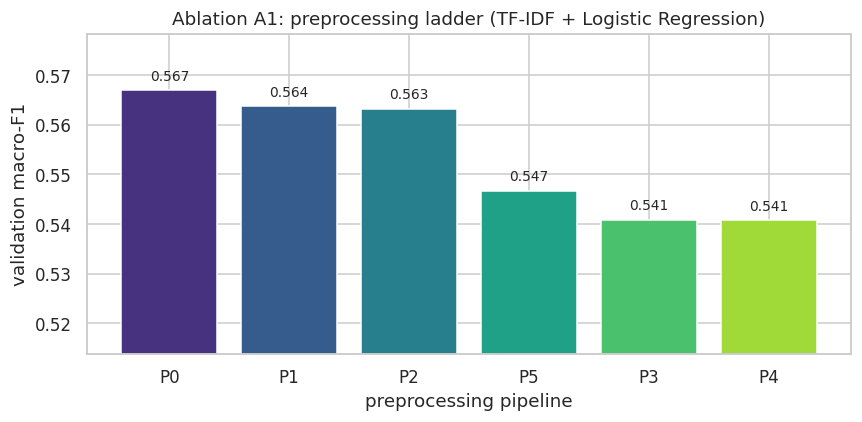

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(LADDER["pipeline"], LADDER["val_macro_f1"], color=sns.color_palette("viridis", len(LADDER)))
ax.set_ylabel("validation macro-F1")
ax.set_xlabel("preprocessing pipeline")
ax.set_title("Ablation A1: preprocessing ladder (TF-IDF + Logistic Regression)")
ax.set_ylim(LADDER["val_macro_f1"].min() * 0.95, LADDER["val_macro_f1"].max() * 1.02)
for i, (p, v) in enumerate(zip(LADDER["pipeline"], LADDER["val_macro_f1"])):
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(OUT / "figures" / "ablation_preprocessing.png", bbox_inches="tight")
plt.show()

---
# 7. Text representations

The spec requires at least two of TF-IDF, Word2Vec and GloVe (§3.6). We implement all three, plus BERT's contextual embeddings in §9.

- **R1 — TF-IDF**, word unigrams and bigrams
- **R2 — GloVe**, pretrained, mean-pooled for classical models and as the `Embedding` initialiser for the recurrent models
- **R3 — Word2Vec**, skip-gram trained **on the training split only**, since training on the full corpus would itself be a leak

In [ ]:
REPS = {}

for k, s in SPLITS.items():
    f = s["frame"]
    vec = TfidfVectorizer(ngram_range=(1, 2), max_features=CONFIG["tfidf_features"],
                          min_df=2, sublinear_tf=True)
    Xtr = vec.fit_transform(f[BEST_PREP].values[s["train"]])
    Xva = vec.transform(f[BEST_PREP].values[s["val"]])
    Xte = vec.transform(f[BEST_PREP].values[s["test"]])
    REPS[(k, "TF-IDF")] = {"train": Xtr, "val": Xva, "test": Xte, "vectorizer": vec}
    print(f"split {k}: TF-IDF matrix {Xtr.shape}, vocabulary {len(vec.vocabulary_)}")

split A: TF-IDF matrix (5588, 10000), vocabulary 10000
split B: TF-IDF matrix (5409, 10000), vocabulary 10000


Download pretrained GloVe vectors through `gensim`. Dimensionality follows `CONFIG['glove_dim']`.

In [ ]:
import gensim.downloader as gensim_api

glove_name = f"glove-wiki-gigaword-{CONFIG['glove_dim']}"
t0 = time.time()
GLOVE = gensim_api.load(glove_name)
print(f"loaded {glove_name} in {time.time()-t0:.0f}s | vocabulary {len(GLOVE.index_to_key)} | dim {GLOVE.vector_size}")

[==================================================] 100.0% 128.1/128.1MB downloaded
loaded glove-wiki-gigaword-100 in 75s | vocabulary 400000 | dim 100


In [ ]:
from gensim.models import Word2Vec

W2V = {}
for k, s in SPLITS.items():
    f = s["frame"]
    corpus = [t.split() for t in f[BEST_PREP].values[s["train"]]]
    t0 = time.time()
    m = Word2Vec(corpus, vector_size=CONFIG["w2v_dim"], window=5, min_count=3,
                 sg=1, workers=4, epochs=5, seed=SEED)
    W2V[k] = m
    print(f"split {k}: in-domain Word2Vec trained in {time.time()-t0:.0f}s | vocabulary {len(m.wv.index_to_key)}")

split A: in-domain Word2Vec trained in 14s | vocabulary 10267
split B: in-domain Word2Vec trained in 14s | vocabulary 9973


Vocabulary coverage. Social-media mental-health text is heavy in slang and misspellings, so general-domain GloVe is expected to miss a meaningful share of tokens. This number motivates the in-domain Word2Vec condition and gives a concrete reason for representation differences in the Results section.

In [ ]:
s = SPLITS["A"]
f = s["frame"]
train_tokens = Counter()
for t in f[BEST_PREP].values[s["train"]]:
    train_tokens.update(t.split())

vocab = set(train_tokens)
total_tok = sum(train_tokens.values())
glove_types = sum(1 for w in vocab if w in GLOVE.key_to_index)
glove_tokens = sum(c for w, c in train_tokens.items() if w in GLOVE.key_to_index)
w2v_types = sum(1 for w in vocab if w in W2V["A"].wv.key_to_index)

COVERAGE = pd.DataFrame([
    {"embedding": f"GloVe {CONFIG['glove_dim']}d", "type_coverage_%": round(glove_types / len(vocab) * 100, 2),
     "token_coverage_%": round(glove_tokens / total_tok * 100, 2)},
    {"embedding": f"Word2Vec {CONFIG['w2v_dim']}d (in-domain)", "type_coverage_%": round(w2v_types / len(vocab) * 100, 2),
     "token_coverage_%": 100.0},
])
COVERAGE.to_csv(OUT / "tables" / "embedding_coverage.csv", index=False)
print("training vocabulary size:", len(vocab))
print()
print(COVERAGE.to_string(index=False))

training vocabulary size: 36882

                embedding  type_coverage_%  token_coverage_%
               GloVe 100d            36.22             80.68
Word2Vec 100d (in-domain)            27.84            100.00


Mean-pooled document vectors, used by the classical models. Out-of-vocabulary tokens are skipped; documents with no in-vocabulary token become zero vectors.

In [ ]:
def mean_pool(texts, kv, dim):
    out = np.zeros((len(texts), dim), dtype=np.float32)
    for i, t in enumerate(texts):
        vs = [kv[w] for w in t.split() if w in kv]
        if vs:
            out[i] = np.mean(vs, axis=0)
    return out

for k, s in SPLITS.items():
    f = s["frame"]
    d = GLOVE.vector_size
    REPS[(k, "GloVe")] = {
        "train": mean_pool(f[BEST_PREP].values[s["train"]], GLOVE, d),
        "val":   mean_pool(f[BEST_PREP].values[s["val"]],   GLOVE, d),
        "test":  mean_pool(f[BEST_PREP].values[s["test"]],  GLOVE, d),
    }
    wv = W2V[k].wv
    dw = wv.vector_size
    REPS[(k, "Word2Vec")] = {
        "train": mean_pool(f[BEST_PREP].values[s["train"]], wv, dw),
        "val":   mean_pool(f[BEST_PREP].values[s["val"]],   wv, dw),
        "test":  mean_pool(f[BEST_PREP].values[s["test"]],  wv, dw),
    }
    print(f"split {k}: GloVe {REPS[(k,'GloVe')]['train'].shape} | Word2Vec {REPS[(k,'Word2Vec')]['train'].shape}")

split A: GloVe (5588, 100) | Word2Vec (5588, 100)
split B: GloVe (5409, 100) | Word2Vec (5409, 100)


---
# 8. Classical machine-learning models

Spec §3.7 requires Random Forest, Logistic Regression and Naive Bayes. We add **LinearSVC** because it is the model family the highest published result on this dataset used, and we cannot re-evaluate that result without reproducing its method.

Each model is trained under **three hyperparameter configurations** (spec §3.8), selected on the validation set, and only the winner touches the test set.

**A note on Naive Bayes.** `MultinomialNB` requires non-negative features, so it cannot consume mean-pooled GloVe or Word2Vec vectors, which have negative components. For those representations we use `GaussianNB` instead. Silently skipping the combination would hide a real modelling constraint.

In [ ]:
from sklearn.naive_bayes import MultinomialNB, ComplementNB, GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def make_classical_configs():
    return {
        "LogisticRegression": [
            ("cfg1", {"C": 0.1,  "max_iter": 1000}),
            ("cfg2", {"C": 1.0,  "max_iter": 1000}),
            ("cfg3", {"C": 10.0, "max_iter": 1000, "class_weight": "balanced"}),
        ],
        "NaiveBayes": [
            ("cfg1", {"alpha": 0.01}),
            ("cfg2", {"alpha": 0.5}),
            ("cfg3", {"alpha": 1.0, "complement": True}),
        ],
        "RandomForest": [
            ("cfg1", {"n_estimators": 100, "max_depth": None, "n_jobs": -1}),
            ("cfg2", {"n_estimators": 300, "max_depth": 30,   "n_jobs": -1}),
            ("cfg3", {"n_estimators": 300, "max_depth": 50,   "n_jobs": -1, "class_weight": "balanced_subsample"}),
        ],
        "LinearSVC": [
            ("cfg1", {"C": 0.1}),
            ("cfg2", {"C": 1.0}),
            ("cfg3", {"C": 1.0, "class_weight": "balanced"}),
        ],
    }

def build_classical(name, params, is_dense):
    p = dict(params)
    if name == "LogisticRegression":
        return LogisticRegression(n_jobs=-1, random_state=SEED, **p)
    if name == "NaiveBayes":
        complement = p.pop("complement", False)
        if is_dense:
            return GaussianNB()
        return ComplementNB(**p) if complement else MultinomialNB(**p)
    if name == "RandomForest":
        return RandomForestClassifier(random_state=SEED, **p)
    if name == "LinearSVC":
        return CalibratedClassifierCV(LinearSVC(random_state=SEED, max_iter=3000, **p), cv=3)
    raise ValueError(name)

print("classical model factory ready")

classical model factory ready


Train every classical model across every representation, split and configuration. Dense embeddings are min-max shifted for `GaussianNB` stability.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

CLASSICAL_CONFIGS = make_classical_configs()
classical_reps = ["TF-IDF", "GloVe", "Word2Vec"]

for split_key in SPLITS:
    s = SPLITS[split_key]
    for rep in classical_reps:
        R = REPS[(split_key, rep)]
        is_dense = rep != "TF-IDF"
        Xtr, Xva, Xte = R["train"], R["val"], R["test"]
        if is_dense:
            sc = MinMaxScaler().fit(Xtr)
            Xtr, Xva, Xte = sc.transform(Xtr), sc.transform(Xva), sc.transform(Xte)

        for name, cfgs in CLASSICAL_CONFIGS.items():
            best = None
            for cfg_id, params in cfgs:
                set_seeds()
                t0 = time.time()
                try:
                    clf = build_classical(name, params, is_dense)
                    clf.fit(Xtr, s["y_train"])
                    pv = clf.predict(Xva)
                    acc = accuracy_score(s["y_val"], pv)
                    mf1 = f1_score(s["y_val"], pv, average="macro", zero_division=0)
                except Exception as e:
                    print(f"  [skip] {name}/{rep}/{cfg_id}: {type(e).__name__}")
                    continue
                secs = time.time() - t0
                log_tuning(name, rep, BEST_PREP, split_key, cfg_id, params, acc, mf1, secs)
                if best is None or mf1 > best["mf1"]:
                    best = {"clf": clf, "mf1": mf1, "params": params, "cfg_id": cfg_id, "secs": secs}

            if best is None:
                continue
            yp = best["clf"].predict(Xte)
            try:
                proba = best["clf"].predict_proba(Xte)
            except Exception:
                proba = None
            record_test(name, rep, BEST_PREP, split_key, best["params"],
                        s["y_test"], yp, proba, best["secs"])

print("\nclassical models complete:", len(TEST_RESULTS), "test evaluations logged")

  -> LogisticRegression [TF-IDF, split A]  acc=0.7379  macroF1=0.6955
  -> NaiveBayes [TF-IDF, split A]  acc=0.6578  macroF1=0.6026
  -> RandomForest [TF-IDF, split A]  acc=0.6444  macroF1=0.5234
  -> LinearSVC [TF-IDF, split A]  acc=0.7421  macroF1=0.6891
  -> LogisticRegression [GloVe, split A]  acc=0.5159  macroF1=0.4360
  -> NaiveBayes [GloVe, split A]  acc=0.3723  macroF1=0.2883
  -> RandomForest [GloVe, split A]  acc=0.6294  macroF1=0.4808
  -> LinearSVC [GloVe, split A]  acc=0.5459  macroF1=0.2842
  -> LogisticRegression [Word2Vec, split A]  acc=0.5234  macroF1=0.4410
  -> NaiveBayes [Word2Vec, split A]  acc=0.4207  macroF1=0.3109
  -> RandomForest [Word2Vec, split A]  acc=0.6511  macroF1=0.5032
  -> LinearSVC [Word2Vec, split A]  acc=0.5659  macroF1=0.3200
  -> LogisticRegression [TF-IDF, split B]  acc=0.7500  macroF1=0.6914
  -> NaiveBayes [TF-IDF, split B]  acc=0.6712  macroF1=0.5556
  -> RandomForest [TF-IDF, split B]  acc=0.6455  macroF1=0.4115
  -> LinearSVC [TF-IDF, split

Tuning log so far. This table is a spec §3.8 deliverable.

In [ ]:
TUNE_DF = pd.DataFrame(TUNING_LOG)
TUNE_DF.to_csv(OUT / "tables" / "tuning_log.csv", index=False)
print("tuning runs logged:", len(TUNE_DF))
TUNE_DF.tail(20)

tuning runs logged: 78


,model,representation,preprocessing,split,config_id,hyperparams,val_accuracy,val_macro_f1,train_time_s,notes
58,NaiveBayes,GloVe,P0,B,cfg2,"{""alpha"": 0.5}",0.3894,0.2927,0.0,
59,NaiveBayes,GloVe,P0,B,cfg3,"{""alpha"": 1.0, ""complement"": true}",0.3894,0.2927,0.0,
60,RandomForest,GloVe,P0,B,cfg1,"{""n_estimators"": 100, ""max_depth"": null, ""n_jobs"": -1}",0.6312,0.3885,7.7,
61,RandomForest,GloVe,P0,B,cfg2,"{""n_estimators"": 300, ""max_depth"": 30, ""n_jobs"": -1}",0.6321,0.3819,19.7,
62,RandomForest,GloVe,P0,B,cfg3,"{""n_estimators"": 300, ""max_depth"": 50, ""n_jobs"": -1, ""class_weight"": ""balanced_subsample""}",0.6312,0.3844,20.1,
63,LinearSVC,GloVe,P0,B,cfg1,"{""C"": 0.1}",0.5515,0.2738,1.2,
64,LinearSVC,GloVe,P0,B,cfg2,"{""C"": 1.0}",0.5609,0.2743,1.6,
65,LinearSVC,GloVe,P0,B,cfg3,"{""C"": 1.0, ""class_weight"": ""balanced""}",0.5592,0.2736,1.5,
66,LogisticRegression,Word2Vec,P0,B,cfg1,"{""C"": 0.1, ""max_iter"": 1000}",0.5437,0.2437,1.6,
67,LogisticRegression,Word2Vec,P0,B,cfg2,"{""C"": 1.0, ""max_iter"": 1000}",0.5695,0.3139,1.9,


---
# 9. Recurrent neural models

Spec §3.7 requires all six of SimpleRNN, GRU, LSTM and their bidirectional variants. Each is trained under three configurations.

The three configurations are chosen so that they double as **ablation A2** (embedding initialisation) at no extra cost:

| Config | Units | Embedding |
|---|---|---|
| `cfg1` | 32 | randomly initialised, trainable |
| `cfg2` | 64 | GloVe, frozen |
| `cfg3` | 128 | GloVe, fine-tuned |

Comparing cfg1 / cfg2 / cfg3 across all six architectures answers whether pretrained general-domain embeddings help on this corpus, given the coverage gap measured in §7.

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM, GRU, Bidirectional,
                                     Dense, Dropout, GlobalMaxPooling1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

print("tensorflow", tf.__version__)
print("GPUs visible to TF:", tf.config.list_physical_devices("GPU"))

tensorflow 2.20.0
GPUs visible to TF: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Tokenise and pad. The tokenizer is fit on the training split only.

In [ ]:
SEQ = {}
for k, s in SPLITS.items():
    f = s["frame"]
    tok = Tokenizer(num_words=CONFIG["vocab_size"], oov_token="<OOV>")
    tok.fit_on_texts(f[BEST_PREP].values[s["train"]])

    def enc(idx):
        return pad_sequences(tok.texts_to_sequences(f[BEST_PREP].values[idx]),
                             maxlen=CONFIG["max_len"], padding="post", truncating="post")

    SEQ[k] = {"tokenizer": tok, "train": enc(s["train"]), "val": enc(s["val"]), "test": enc(s["test"])}
    lens = [len(x.split()) for x in f[BEST_PREP].values[s["train"]]]
    trunc = np.mean(np.array(lens) > CONFIG["max_len"]) * 100
    print(f"split {k}: sequences {SEQ[k]['train'].shape} | vocabulary {min(len(tok.word_index), CONFIG['vocab_size'])} | truncated {trunc:.1f}%")

split A: sequences (5588, 128) | vocabulary 18694 | truncated 29.1%
split B: sequences (5409, 128) | vocabulary 18619 | truncated 29.1%


Build the GloVe embedding matrix aligned to each tokenizer's vocabulary.

In [ ]:
EMB_MATRIX = {}
for k in SPLITS:
    tok = SEQ[k]["tokenizer"]
    dim = GLOVE.vector_size
    n_words = min(len(tok.word_index) + 1, CONFIG["vocab_size"])
    M = np.zeros((n_words, dim), dtype=np.float32)
    hit = 0
    for w, i in tok.word_index.items():
        if i >= n_words:
            continue
        if w in GLOVE.key_to_index:
            M[i] = GLOVE[w]
            hit += 1
    EMB_MATRIX[k] = M
    print(f"split {k}: embedding matrix {M.shape} | GloVe hits {hit}/{n_words-1} ({hit/(n_words-1)*100:.1f}%)")

split A: embedding matrix (18695, 100) | GloVe hits 15224/18694 (81.4%)
split B: embedding matrix (18620, 100) | GloVe hits 15155/18619 (81.4%)


A single builder covers all six architectures. `bidirectional` and the recurrent cell type are parameters, so the six required models differ only by argument.

In [ ]:
CELLS = {"SimpleRNN": SimpleRNN, "GRU": GRU, "LSTM": LSTM}

def build_rnn(cell_name, bidirectional, units, emb_mode, split_key, dropout=0.4, lr=1e-3):
    tok = SEQ[split_key]["tokenizer"]
    n_words = min(len(tok.word_index) + 1, CONFIG["vocab_size"])
    Cell = CELLS[cell_name]

    if emb_mode == "random":
        emb = Embedding(n_words, 100, input_length=CONFIG["max_len"])
    else:
        emb = Embedding(n_words, GLOVE.vector_size, input_length=CONFIG["max_len"],
                        weights=[EMB_MATRIX[split_key]], trainable=(emb_mode == "glove_trainable"))

    core = Cell(units, return_sequences=False)
    if bidirectional:
        core = Bidirectional(core)

    model = Sequential([emb, core, Dropout(dropout), Dense(64, activation="relu"),
                        Dropout(dropout), Dense(N_CLASSES, activation="softmax")])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    return model

RNN_CONFIGS = [
    ("cfg1", {"units": 32,  "emb_mode": "random",          "dropout": 0.3, "lr": 1e-3}),
    ("cfg2", {"units": 64,  "emb_mode": "glove_frozen",    "dropout": 0.4, "lr": 1e-3}),
    ("cfg3", {"units": 128, "emb_mode": "glove_trainable", "dropout": 0.5, "lr": 5e-4}),
]

RNN_MODELS = [
    ("SimpleRNN",   "SimpleRNN", False),
    ("GRU",         "GRU",       False),
    ("LSTM",        "LSTM",      False),
    ("BiSimpleRNN", "SimpleRNN", True),
    ("BiGRU",       "GRU",       True),
    ("BiLSTM",      "LSTM",      True),
]

print("architectures to train:", [m[0] for m in RNN_MODELS])
print("configurations per architecture:", len(RNN_CONFIGS))
print("total recurrent runs:", len(RNN_MODELS) * len(RNN_CONFIGS) * len(SPLITS))

architectures to train: ['SimpleRNN', 'GRU', 'LSTM', 'BiSimpleRNN', 'BiGRU', 'BiLSTM']
configurations per architecture: 3
total recurrent runs: 36


Class weights to counter the imbalance measured in §2.2. Applied to every recurrent model.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

CLASS_WEIGHTS = {}
for k, s in SPLITS.items():
    cw = compute_class_weight("balanced", classes=np.arange(N_CLASSES), y=s["y_train"])
    CLASS_WEIGHTS[k] = {i: float(w) for i, w in enumerate(cw)}
print("split A class weights:", {CLASS_NAMES[i]: round(v, 2) for i, v in CLASS_WEIGHTS["A"].items()})

split A class weights: {'Anxiety': 1.98, 'Bipolar': 2.77, 'Depression': 0.49, 'Normal': 0.46, 'Personality disorder': 7.19, 'Stress': 2.84, 'Suicidal': 0.71}


Training loop. Early stopping restores the best weights, so the reported epoch count is the epoch actually selected.

In [ ]:
RNN_HISTORIES = {}

for split_key in SPLITS:
    s = SPLITS[split_key]
    ytr_c = to_categorical(s["y_train"], N_CLASSES)
    yva_c = to_categorical(s["y_val"], N_CLASSES)

    for disp_name, cell_name, bidir in RNN_MODELS:
        best = None
        for cfg_id, params in RNN_CONFIGS:
            set_seeds()
            tf.keras.backend.clear_session()
            t0 = time.time()
            model = build_rnn(cell_name, bidir, split_key=split_key, **params)
            es = EarlyStopping(monitor="val_loss", patience=CONFIG["rnn_patience"],
                               restore_best_weights=True, verbose=0)
            hist = model.fit(SEQ[split_key]["train"], ytr_c,
                             validation_data=(SEQ[split_key]["val"], yva_c),
                             epochs=CONFIG["rnn_epochs"], batch_size=64,
                             class_weight=CLASS_WEIGHTS[split_key], callbacks=[es], verbose=0)
            secs = time.time() - t0
            pv = model.predict(SEQ[split_key]["val"], verbose=0).argmax(1)
            acc = accuracy_score(s["y_val"], pv)
            mf1 = f1_score(s["y_val"], pv, average="macro", zero_division=0)
            log_tuning(disp_name, "GloVe/seq", BEST_PREP, split_key, cfg_id, params, acc, mf1, secs,
                       f"epochs_run={len(hist.history['loss'])}")
            print(f"  {disp_name:12s} split {split_key} {cfg_id}: val_acc={acc:.4f} val_f1={mf1:.4f} ({secs:.0f}s)")
            if best is None or mf1 > best["mf1"]:
                best = {"model": model, "mf1": mf1, "params": params, "secs": secs, "hist": hist}

        proba = best["model"].predict(SEQ[split_key]["test"], verbose=0)
        record_test(disp_name, "GloVe/seq", BEST_PREP, split_key, best["params"],
                    s["y_test"], proba.argmax(1), proba, best["secs"])
        RNN_HISTORIES[(split_key, disp_name)] = best["hist"].history

print("\nrecurrent models complete")

  SimpleRNN    split A cfg1: val_acc=0.4407 val_f1=0.2454 (16s)
  SimpleRNN    split A cfg2: val_acc=0.3447 val_f1=0.1498 (17s)
  SimpleRNN    split A cfg3: val_acc=0.3689 val_f1=0.1795 (14s)
  -> SimpleRNN [GloVe/seq, split A]  acc=0.4282  macroF1=0.2447
  GRU          split A cfg1: val_acc=0.4349 val_f1=0.2201 (11s)
  GRU          split A cfg2: val_acc=0.4257 val_f1=0.2222 (8s)
  GRU          split A cfg3: val_acc=0.4299 val_f1=0.1970 (8s)
  -> GRU [GloVe/seq, split A]  acc=0.3940  macroF1=0.1875
  LSTM         split A cfg1: val_acc=0.3255 val_f1=0.1102 (6s)
  LSTM         split A cfg2: val_acc=0.4516 val_f1=0.2476 (7s)
  LSTM         split A cfg3: val_acc=0.4065 val_f1=0.2542 (9s)
  -> LSTM [GloVe/seq, split A]  acc=0.3948  macroF1=0.2377
  BiSimpleRNN  split A cfg1: val_acc=0.5668 val_f1=0.4180 (17s)
  BiSimpleRNN  split A cfg2: val_acc=0.4524 val_f1=0.3166 (18s)
  BiSimpleRNN  split A cfg3: val_acc=0.4249 val_f1=0.2867 (18s)
  -> BiSimpleRNN [GloVe/seq, split A]  acc=0.5551  macro

Training curves for the best configuration of each architecture on Split-B.

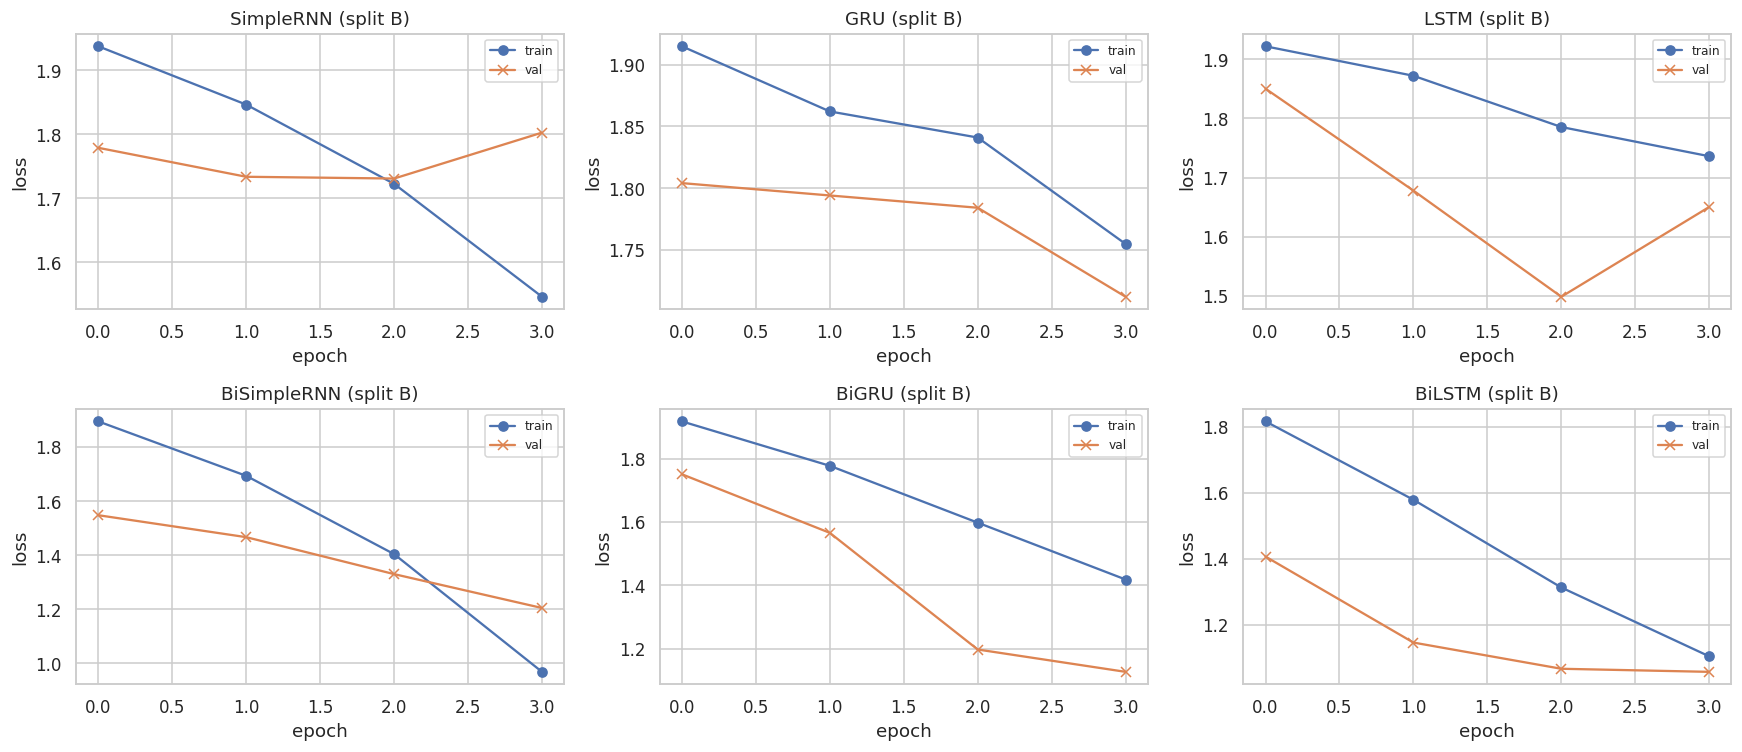

In [ ]:
key_split = "B" if "B" in SPLITS else "A"
avail = [(k, n) for (k, n) in RNN_HISTORIES if k == key_split]
if avail:
    fig, axes = plt.subplots(2, 3, figsize=(16, 7))
    axes = axes.reshape(-1)
    for ax, (k, n) in zip(axes, avail[:6]):
        h = RNN_HISTORIES[(k, n)]
        ax.plot(h["loss"], marker="o", label="train")
        ax.plot(h["val_loss"], marker="x", label="val")
        ax.set_title(f"{n} (split {k})")
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss")
        ax.legend(fontsize=8)
    for j in range(len(avail[:6]), len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.savefig(OUT / "figures" / "rnn_training_curves.png", bbox_inches="tight")
    plt.show()
else:
    print("no histories to plot")

---
# 10. BERT

Spec §3.7 requires BERT Base. We fine-tune `bert-base-uncased` end to end.

Two deliberate choices, both worth stating in the report:

- BERT receives **P1 only**. Stopword removal and punctuation stripping damage a model whose tokenizer and attention machinery depend on exactly those signals.
- Sequences are truncated at 128 tokens. The truncation rate is reported below so the choice is documented rather than arbitrary.

In [ ]:
BERT_OK = CONFIG["run_bert"]
if BERT_OK:
    try:
        import torch
        from torch.utils.data import Dataset, DataLoader
        from transformers import AutoTokenizer, AutoModelForSequenceClassification
        DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print("device:", DEVICE)
        if DEVICE.type == "cpu":
            print("WARNING: BERT on CPU is very slow. Consider CONFIG['run_bert'] = False.")
    except Exception as e:
        BERT_OK = False
        print("transformers unavailable:", e)
else:
    print("BERT disabled in CONFIG")

device: cuda


In [ ]:
if BERT_OK:
    class TextDS(Dataset):
        def __init__(self, texts, labels, tokenizer, max_len):
            self.enc = tokenizer(list(texts), truncation=True, padding="max_length",
                                 max_length=max_len, return_tensors="pt")
            self.labels = torch.tensor(labels, dtype=torch.long)
        def __len__(self):
            return len(self.labels)
        def __getitem__(self, i):
            item = {k: v[i] for k, v in self.enc.items()}
            item["labels"] = self.labels[i]
            return item

    def run_bert(model_name, split_key, lr, epochs, batch, max_len):
        set_seeds()
        s = SPLITS[split_key]
        f = s["frame"]
        tok = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=N_CLASSES).to(DEVICE)

        ds_tr = TextDS(f["P1"].values[s["train"]], s["y_train"], tok, max_len)
        ds_va = TextDS(f["P1"].values[s["val"]],   s["y_val"],   tok, max_len)
        ds_te = TextDS(f["P1"].values[s["test"]],  s["y_test"],  tok, max_len)
        dl_tr = DataLoader(ds_tr, batch_size=batch, shuffle=True)
        dl_va = DataLoader(ds_va, batch_size=batch * 2)
        dl_te = DataLoader(ds_te, batch_size=batch * 2)

        opt = torch.optim.AdamW(model.parameters(), lr=lr)
        scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
        t0 = time.time()
        for ep in range(epochs):
            model.train()
            tot = 0.0
            for bt in dl_tr:
                bt = {k: v.to(DEVICE) for k, v in bt.items()}
                opt.zero_grad()
                with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                    out = model(**bt)
                scaler.scale(out.loss).backward()
                scaler.step(opt)
                scaler.update()
                tot += out.loss.item()
            print(f"    epoch {ep+1}/{epochs} train_loss={tot/len(dl_tr):.4f}")

        def infer(dl):
            model.eval()
            ps = []
            with torch.no_grad():
                for bt in dl:
                    bt = {k: v.to(DEVICE) for k, v in bt.items()}
                    lg = model(**{k: v for k, v in bt.items() if k != "labels"}).logits
                    ps.append(torch.softmax(lg.float(), -1).cpu().numpy())
            return np.vstack(ps)

        return infer(dl_va), infer(dl_te), time.time() - t0

    print("BERT helpers ready")

BERT helpers ready


In [ ]:
if BERT_OK:
    tok_check = AutoTokenizer.from_pretrained("bert-base-uncased")
    s = SPLITS["A"]
    samp = s["frame"]["P1"].values[s["train"]][:2000]
    lens = [len(tok_check.encode(t, truncation=False)) for t in samp]
    print("WordPiece token length: median %d | 90th pct %d | 99th pct %d"
          % (np.median(lens), np.percentile(lens, 90), np.percentile(lens, 99)))
    print("share truncated at max_len=%d: %.1f%%"
          % (CONFIG["bert_max_len"], np.mean(np.array(lens) > CONFIG["bert_max_len"]) * 100))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (696 > 512). Running this sequence through the model will result in indexing errors


WordPiece token length: median 62 | 90th pct 309 | 99th pct 954
share truncated at max_len=128: 31.6%


In [ ]:
BERT_CONFIGS = [
    ("cfg1", {"lr": 2e-5, "epochs": CONFIG["bert_epochs"],     "batch": CONFIG["bert_batch"], "max_len": CONFIG["bert_max_len"]}),
    ("cfg2", {"lr": 3e-5, "epochs": CONFIG["bert_epochs"],     "batch": CONFIG["bert_batch"], "max_len": CONFIG["bert_max_len"]}),
    ("cfg3", {"lr": 5e-5, "epochs": max(1, CONFIG["bert_epochs"] - 1), "batch": 16,           "max_len": CONFIG["bert_max_len"]}),
]

if BERT_OK:
    for split_key in SPLITS:
        s = SPLITS[split_key]
        best = None
        for cfg_id, params in BERT_CONFIGS:
            print(f"  BERT split {split_key} {cfg_id}: {params}")
            pv, pt, secs = run_bert("bert-base-uncased", split_key, **params)
            acc = accuracy_score(s["y_val"], pv.argmax(1))
            mf1 = f1_score(s["y_val"], pv.argmax(1), average="macro", zero_division=0)
            log_tuning("BERT-base", "BERT", "P1", split_key, cfg_id, params, acc, mf1, secs)
            print(f"    val_acc={acc:.4f} val_f1={mf1:.4f} ({secs:.0f}s)")
            if best is None or mf1 > best["mf1"]:
                best = {"mf1": mf1, "params": params, "proba": pt, "secs": secs}
        record_test("BERT-base", "BERT", "P1", split_key, best["params"],
                    s["y_test"], best["proba"].argmax(1), best["proba"], best["secs"])
else:
    print("BERT skipped")

  BERT split A cfg1: {'lr': 2e-05, 'epochs': 1, 'batch': 32, 'max_len': 128}


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch 1/1 train_loss=1.0146
    val_acc=0.7281 val_f1=0.4555 (54s)
  BERT split B cfg3: {'lr': 5e-05, 'epochs': 1, 'batch': 16, 'max_len': 128}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch 1/1 train_loss=0.8509
    val_acc=0.7479 val_f1=0.6051 (60s)
  -> BERT-base [BERT, split B]  acc=0.7748  macroF1=0.6524


---
# 11. Ensemble

Spec §4 lists an ensemble of the best-performing models as a bonus criterion. We use **soft voting** over the top three *heterogeneous* models — averaging three recurrent variants would buy little, because their errors correlate.

Improvement is not merely asserted. **McNemar's test** on the paired test predictions establishes whether the ensemble's gain over the best single model is statistically significant.

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

RES_DF = pd.DataFrame(TEST_RESULTS)
RES_DF.to_csv(OUT / "tables" / "test_results.csv", index=False)

def load_proba(model, rep, split):
    tag = f"{model}__{rep}__{split}".replace(" ", "_").replace("/", "-")
    p = OUT / "predictions" / f"{tag}.csv"
    if not p.exists():
        return None
    d = pd.read_csv(p)
    cols = [f"p_{c}" for c in CLASS_NAMES]
    if not all(c in d.columns for c in cols):
        return None
    return d["y_true"].values, d[cols].values

ENSEMBLE_ROWS = []
for split_key in SPLITS:
    sub = RES_DF[RES_DF.split == split_key].sort_values("test_macro_f1", ascending=False)
    picks, seen = [], set()
    for _, r in sub.iterrows():
        fam = "rnn" if r["model"] in [m[0] for m in RNN_MODELS] else r["model"]
        if fam in seen:
            continue
        got = load_proba(r["model"], r["representation"], split_key)
        if got is None:
            continue
        picks.append((r["model"], r["representation"], got))
        seen.add(fam)
        if len(picks) == 3:
            break

    if len(picks) < 2:
        print(f"split {split_key}: not enough probabilistic models to ensemble")
        continue

    y_true = picks[0][2][0]
    avg = np.mean([p[2][1] for p in picks], axis=0)
    y_ens = avg.argmax(1)

    best_row = sub.iloc[0]
    best_pred = load_proba(best_row["model"], best_row["representation"], split_key)[1].argmax(1)

    both_right = int(np.sum((best_pred == y_true) & (y_ens == y_true)))
    only_best  = int(np.sum((best_pred == y_true) & (y_ens != y_true)))
    only_ens   = int(np.sum((best_pred != y_true) & (y_ens == y_true)))
    both_wrong = int(np.sum((best_pred != y_true) & (y_ens != y_true)))
    if only_best + only_ens == 0:
        stat, pval = float("nan"), 1.0
    else:
        res = mcnemar(np.array([[both_right, only_best], [only_ens, both_wrong]]),
                      exact=(only_best + only_ens < 25), correction=True)
        stat, pval = float(res.statistic), float(res.pvalue)

    print(f"\nsplit {split_key} ensemble members: {[p[0] for p in picks]}")
    print(f"  best single ({best_row['model']}) acc = {best_row['test_accuracy']:.4f}")
    print(f"  soft-vote ensemble        acc = {accuracy_score(y_true, y_ens):.4f}")
    print(f"  discordant pairs: ensemble-only-correct={only_ens}, single-only-correct={only_best}")
    print(f"  McNemar statistic = {stat:.3f}, p = {pval:.4g}")

    record_test("Ensemble (soft-vote)", "+".join(p[1] for p in picks), BEST_PREP, split_key,
                {"members": [p[0] for p in picks]}, y_true, y_ens, avg, None)
    ENSEMBLE_ROWS.append({"split": split_key, "members": ", ".join(p[0] for p in picks),
                          "best_single": best_row["model"],
                          "best_single_acc": best_row["test_accuracy"],
                          "ensemble_acc": round(accuracy_score(y_true, y_ens), 4),
                          "mcnemar_p": pval})

ENS_DF = pd.DataFrame(ENSEMBLE_ROWS)
if len(ENS_DF):
    ENS_DF.to_csv(OUT / "tables" / "ensemble.csv", index=False)
ENS_DF


split A ensemble members: ['LogisticRegression', 'LinearSVC', 'BERT-base']
  best single (LogisticRegression) acc = 0.7379
  soft-vote ensemble        acc = 0.7671
  discordant pairs: ensemble-only-correct=71, single-only-correct=36
  McNemar statistic = 10.804, p = 0.001013
  -> Ensemble (soft-vote) [TF-IDF+TF-IDF+BERT, split A]  acc=0.7671  macroF1=0.7320

split B ensemble members: ['LogisticRegression', 'LinearSVC', 'BERT-base']
  best single (LogisticRegression) acc = 0.7500
  soft-vote ensemble        acc = 0.7902
  discordant pairs: ensemble-only-correct=65, single-only-correct=18
  McNemar statistic = 25.494, p = 4.438e-07
  -> Ensemble (soft-vote) [TF-IDF+TF-IDF+BERT, split B]  acc=0.7902  macroF1=0.7370


,split,members,best_single,best_single_acc,ensemble_acc,mcnemar_p
0,A,"LogisticRegression, LinearSVC, BERT-base",LogisticRegression,0.7379,0.7671,1.012953e-03
1,B,"LogisticRegression, LinearSVC, BERT-base",LogisticRegression,0.7500,0.7902,4.437663e-07


---
# 12. Results

Spec §3.9 requires accuracy, F1, confusion matrices and full classification reports for every model, plus identification of the best and worst performers and a discussion grounded in the EDA.

In [ ]:
RES_DF = pd.DataFrame(TEST_RESULTS)
RES_DF.to_csv(OUT / "tables" / "test_results.csv", index=False)

MASTER = RES_DF.pivot_table(index=["model", "representation"], columns="split",
                            values=["test_accuracy", "test_macro_f1"]).round(4)
MASTER.columns = [f"{a.replace('test_','')}_{b}" for a, b in MASTER.columns]
if "accuracy_A" in MASTER.columns and "accuracy_B" in MASTER.columns:
    MASTER["leakage_delta"] = (MASTER["accuracy_A"] - MASTER["accuracy_B"]).round(4)
MASTER = MASTER.sort_values(MASTER.columns[-1] if "leakage_delta" in MASTER.columns else "macro_f1_A",
                            ascending=False)
MASTER.to_csv(OUT / "tables" / "master_comparison.csv")
MASTER

accuracy_A  accuracy_B  macro_f1_A  macro_f1_B  leakage_delta
model                representation                                                                   
SimpleRNN            GloVe/seq               0.4282      0.3442      0.2447      0.1457         0.0840
BiLSTM               GloVe/seq               0.5985      0.5488      0.4913      0.4280         0.0497
BiSimpleRNN          GloVe/seq               0.5551      0.5077      0.4383      0.3474         0.0474
RandomForest         GloVe                   0.6294      0.5933      0.4808      0.3634         0.0361
                     Word2Vec                0.6511      0.6267      0.5032      0.3989         0.0244
LinearSVC            GloVe                   0.5459      0.5265      0.2842      0.2796         0.0194
                     Word2Vec                0.5659      0.5522      0.3200      0.2746         0.0137
BiGRU                GloVe/seq               0.5710      0.5599      0.4737      0.4492         0.0111
LogisticRegression   GloVe                   0.5159      0.5128      0.4360      0.4495         0.0031
RandomForest         TF-IDF                  0.6444      0.6455      0.5234      0.4115        -0.0011
LSTM                 GloVe/seq               0.3948      0.3981      0.2377      0.2407        -0.0033
LinearSVC            TF-IDF                  0.7421      0.7466      0.6891      0.6741        -0.0045
LogisticRegression   TF-IDF                  0.7379      0.7500      0.6955      0.6914        -0.0121
NaiveBayes           TF-IDF                  0.6578      0.6712      0.6026      0.5556        -0.0134
LogisticRegression   Word2Vec                0.5234      0.5394      0.4410      0.4468        -0.0160
NaiveBayes           GloVe                   0.3723      0.3887      0.2883      0.2894        -0.0164
                     Word2Vec                0.4207      0.4392      0.3109      0.3251        -0.0185
GRU                  GloVe/seq               0.3940      0.4152      0.1875      0.1974        -0.0212
Ensemble (soft-vote) TF-IDF+TF-IDF+BERT      0.7671      0.7902      0.7320      0.7370        -0.0231
BERT-base            BERT                    0.7220      0.7748      0.6244      0.6524        -0.0528

### Best and worst performing models

In [ ]:
for split_key in SPLITS:
    sub = RES_DF[RES_DF.split == split_key].sort_values("test_macro_f1", ascending=False)
    print(f"--- SPLIT {split_key} ({SPLITS[split_key]['desc']}) ---")
    print(f"  BEST : {sub.iloc[0]['model']} [{sub.iloc[0]['representation']}] "
          f"acc={sub.iloc[0]['test_accuracy']:.4f} macroF1={sub.iloc[0]['test_macro_f1']:.4f}")
    print(f"  WORST: {sub.iloc[-1]['model']} [{sub.iloc[-1]['representation']}] "
          f"acc={sub.iloc[-1]['test_accuracy']:.4f} macroF1={sub.iloc[-1]['test_macro_f1']:.4f}")
    print(f"  no-text baseline: acc={NOTEXT_ACC:.4f} | majority: acc={MAJORITY_BASELINE:.4f}\n")

--- SPLIT A (naive stratified) ---
  BEST : Ensemble (soft-vote) [TF-IDF+TF-IDF+BERT] acc=0.7671 macroF1=0.7320
  WORST: GRU [GloVe/seq] acc=0.3940 macroF1=0.1875
  no-text baseline: acc=0.4579 | majority: acc=0.3102

--- SPLIT B (dedup + group-aware) ---
  BEST : Ensemble (soft-vote) [TF-IDF+TF-IDF+BERT] acc=0.7902 macroF1=0.7370
  WORST: SimpleRNN [GloVe/seq] acc=0.3442 macroF1=0.1457
  no-text baseline: acc=0.4579 | majority: acc=0.3102



### RQ1 — how much accuracy is leakage?

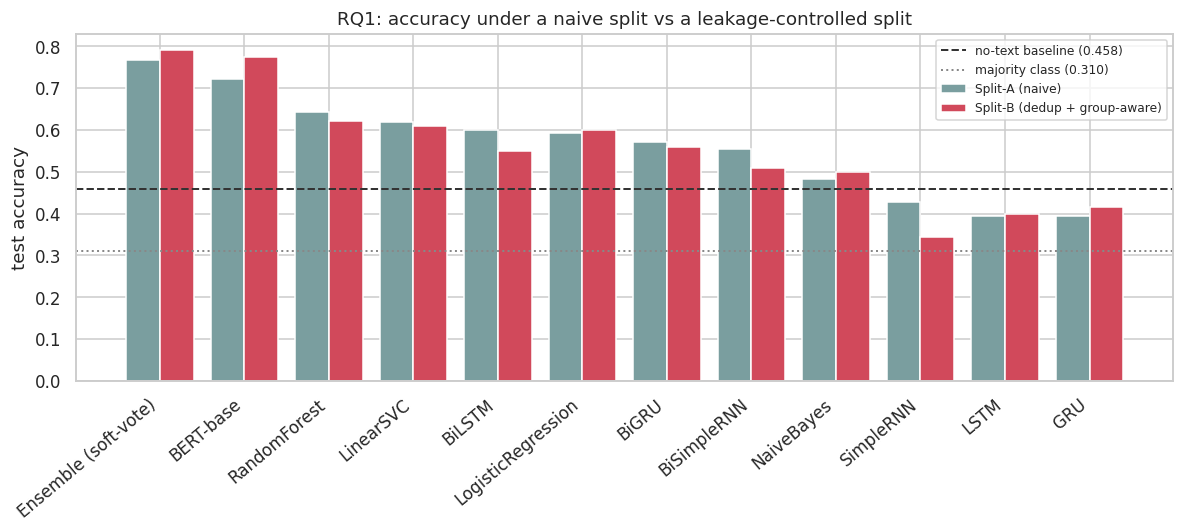

split                        A         B   delta
model                                           
Ensemble (soft-vote)  0.767100  0.790200 -0.0231
BERT-base             0.722000  0.774800 -0.0528
RandomForest          0.641633  0.621833  0.0198
LinearSVC             0.617967  0.608433  0.0095
BiLSTM                0.598500  0.548800  0.0497
LogisticRegression    0.592400  0.600733 -0.0083
BiGRU                 0.571000  0.559900  0.0111
BiSimpleRNN           0.555100  0.507700  0.0474
NaiveBayes            0.483600  0.499700 -0.0161
SimpleRNN             0.428200  0.344200  0.0840
LSTM                  0.394800  0.398100 -0.0033
GRU                   0.394000  0.415200 -0.0212

mean accuracy drop from Split-A to Split-B: 0.0081
largest drop: SimpleRNN (0.0840)
smallest drop: BERT-base (-0.0528)


In [ ]:
if "B" in SPLITS:
    piv = RES_DF.pivot_table(index="model", columns="split", values="test_accuracy")
    piv = piv.dropna().sort_values("A", ascending=False)
    piv["delta"] = (piv["A"] - piv["B"]).round(4)

    fig, ax = plt.subplots(figsize=(11, 5))
    x = np.arange(len(piv))
    ax.bar(x - 0.2, piv["A"], 0.4, label="Split-A (naive)", color="#7a9e9f")
    ax.bar(x + 0.2, piv["B"], 0.4, label="Split-B (dedup + group-aware)", color="#d1495b")
    ax.axhline(NOTEXT_ACC, ls="--", c="#333", lw=1.3, label=f"no-text baseline ({NOTEXT_ACC:.3f})")
    ax.axhline(MAJORITY_BASELINE, ls=":", c="#888", lw=1.3, label=f"majority class ({MAJORITY_BASELINE:.3f})")
    ax.set_xticks(x)
    ax.set_xticklabels(piv.index, rotation=40, ha="right")
    ax.set_ylabel("test accuracy")
    ax.set_title("RQ1: accuracy under a naive split vs a leakage-controlled split")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT / "figures" / "rq1_leakage_delta.png", bbox_inches="tight")
    plt.show()

    print(piv.to_string())
    print("\nmean accuracy drop from Split-A to Split-B: %.4f" % piv["delta"].mean())
    print("largest drop: %s (%.4f)" % (piv["delta"].idxmax(), piv["delta"].max()))
    print("smallest drop: %s (%.4f)" % (piv["delta"].idxmin(), piv["delta"].min()))

### Confusion matrices for the best model under each protocol

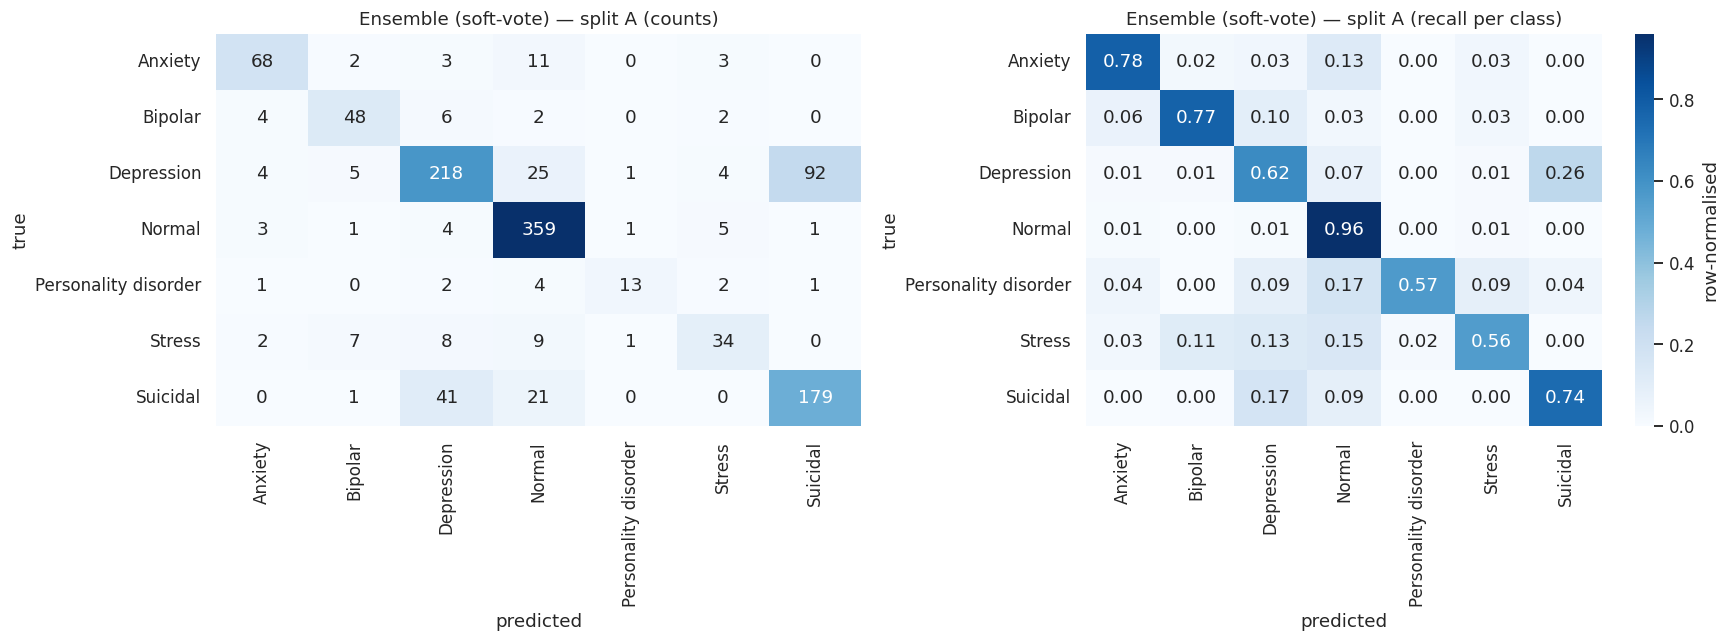


CLASSIFICATION REPORT — Ensemble (soft-vote) — split A
                      precision    recall  f1-score   support

             Anxiety      0.829     0.782     0.805        87
             Bipolar      0.750     0.774     0.762        62
          Depression      0.773     0.625     0.691       349
              Normal      0.833     0.960     0.892       374
Personality disorder      0.812     0.565     0.667        23
              Stress      0.680     0.557     0.613        61
            Suicidal      0.656     0.740     0.695       242

            accuracy                          0.767      1198
           macro avg      0.762     0.715     0.732      1198
        weighted avg      0.767     0.767     0.762      1198



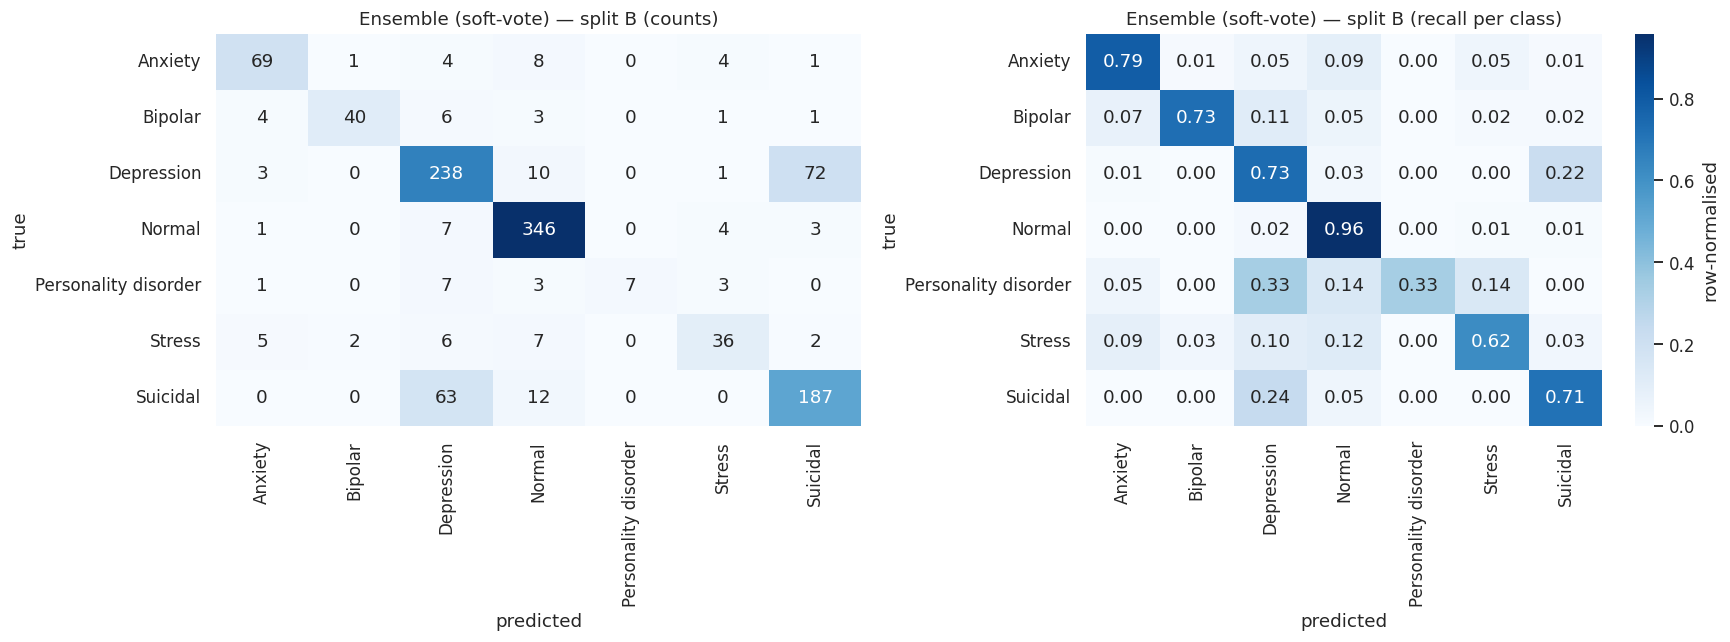


CLASSIFICATION REPORT — Ensemble (soft-vote) — split B
                      precision    recall  f1-score   support

             Anxiety      0.831     0.793     0.812        87
             Bipolar      0.930     0.727     0.816        55
          Depression      0.719     0.735     0.727       324
              Normal      0.889     0.958     0.923       361
Personality disorder      1.000     0.333     0.500        21
              Stress      0.735     0.621     0.673        58
            Suicidal      0.703     0.714     0.708       262

            accuracy                          0.790      1168
           macro avg      0.830     0.697     0.737      1168
        weighted avg      0.792     0.790     0.787      1168



In [ ]:
for split_key in SPLITS:
    sub = RES_DF[RES_DF.split == split_key].sort_values("test_macro_f1", ascending=False)
    top = sub.iloc[0]
    got = load_proba(top["model"], top["representation"], split_key)
    if got is None:
        continue
    y_true, proba = got
    y_pred = proba.argmax(1)

    cm = confusion_matrix(y_true, y_pred)
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, ax=ax[0], cbar=False)
    ax[0].set_title(f"{top['model']} — split {split_key} (counts)")
    sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, ax=ax[1], cbar_kws={"label": "row-normalised"})
    ax[1].set_title(f"{top['model']} — split {split_key} (recall per class)")
    for a in ax:
        a.set_xlabel("predicted")
        a.set_ylabel("true")
    plt.tight_layout()
    plt.savefig(OUT / "figures" / f"confusion_{split_key}.png", bbox_inches="tight")
    plt.show()

    print(f"\nCLASSIFICATION REPORT — {top['model']} — split {split_key}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3, zero_division=0))

### Grounding the results in the EDA

Spec §3.9 asks that the discussion of which configurations outperformed others be grounded in the EDA findings. We test the §2.8 prediction directly: classes whose unigram distributions had the lowest Jensen–Shannon divergence should be the ones the best model confuses most.

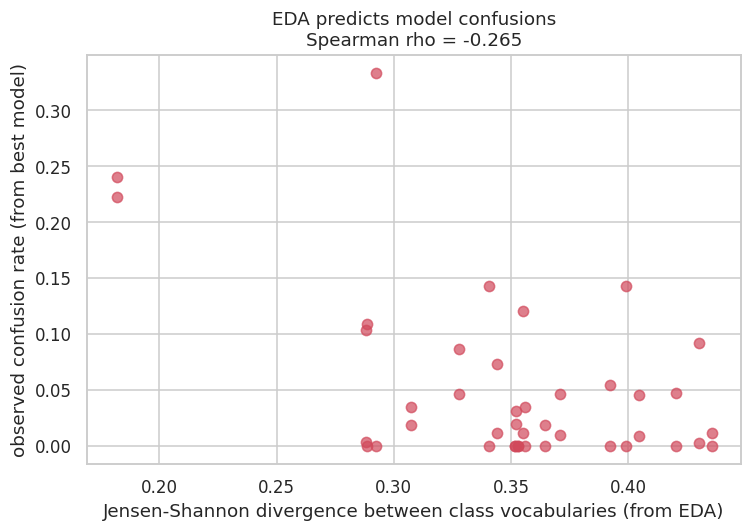

most-confused class pairs:
                true       pred  confusion_rate    jsd
Personality disorder Depression          0.3333 0.2926
            Suicidal Depression          0.2405 0.1817
          Depression   Suicidal          0.2222 0.1817
Personality disorder     Stress          0.1429 0.3407
Personality disorder     Normal          0.1429 0.3990
              Stress     Normal          0.1207 0.3552
             Bipolar Depression          0.1091 0.2885
              Stress Depression          0.1034 0.2880


In [ ]:
split_key = "B" if "B" in SPLITS else "A"
sub = RES_DF[RES_DF.split == split_key].sort_values("test_macro_f1", ascending=False)
got = load_proba(sub.iloc[0]["model"], sub.iloc[0]["representation"], split_key)

if got is not None:
    y_true, proba = got
    y_pred = proba.argmax(1)
    cm = confusion_matrix(y_true, y_pred)
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    rows = []
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            if i == j:
                continue
            ci, cj = CLASS_NAMES[i], CLASS_NAMES[j]
            if ci in jsd_df.index and cj in jsd_df.columns:
                rows.append({"true": ci, "pred": cj,
                             "confusion_rate": round(cmn[i, j], 4),
                             "jsd": round(jsd_df.loc[ci, cj], 4)})
    CONF_JSD = pd.DataFrame(rows)
    r = CONF_JSD["confusion_rate"].corr(CONF_JSD["jsd"], method="spearman")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(CONF_JSD["jsd"], CONF_JSD["confusion_rate"], alpha=0.7, s=45, color="#d1495b")
    ax.set_xlabel("Jensen-Shannon divergence between class vocabularies (from EDA)")
    ax.set_ylabel("observed confusion rate (from best model)")
    ax.set_title(f"EDA predicts model confusions\nSpearman rho = {r:.3f}")
    plt.tight_layout()
    plt.savefig(OUT / "figures" / "jsd_vs_confusion.png", bbox_inches="tight")
    plt.show()

    print("most-confused class pairs:")
    print(CONF_JSD.sort_values("confusion_rate", ascending=False).head(8).to_string(index=False))
    CONF_JSD.to_csv(OUT / "tables" / "jsd_vs_confusion.csv", index=False)

---
# 13. Ablation A3 — how much of the signal is style rather than symptoms?

We mask every token that is **not** a closed-class function word (stopwords and punctuation), destroying all content vocabulary while preserving syntactic and stylistic fingerprints. Whatever accuracy survives cannot come from symptom language; it comes from writing style, which tracks the source dataset.

In [ ]:
set_seeds()
s = SPLITS["B" if "B" in SPLITS else "A"]
f = s["frame"]

def function_words_only(t):
    return " ".join(w for w in p2(t).split() if w in STOPWORDS_EN)

fw_train = [function_words_only(t) for t in f["text"].values[s["train"]]]
fw_test  = [function_words_only(t) for t in f["text"].values[s["test"]]]

vec_fw = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=2)
Xtr_fw = vec_fw.fit_transform(fw_train)
Xte_fw = vec_fw.transform(fw_test)

clf_fw = LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1)
clf_fw.fit(Xtr_fw, s["y_train"])
pred_fw = clf_fw.predict(Xte_fw)
STYLE_ACC = accuracy_score(s["y_test"], pred_fw)

full_best = RES_DF[RES_DF.split == s and False] if False else None
best_acc = RES_DF[RES_DF.split == ("B" if "B" in SPLITS else "A")]["test_accuracy"].max()

print("example of masked text:")
print("  original:", f["text"].values[s['train']][0][:150])
print("  masked  :", fw_train[0][:150])
print()
print("majority baseline                : %.4f" % MAJORITY_BASELINE)
print("no-text baseline (D3)            : %.4f" % NOTEXT_ACC)
print("FUNCTION-WORDS-ONLY (A3)         : %.4f" % STYLE_ACC)
print("best full-text model             : %.4f" % best_acc)
print()
print("share of best model's accuracy reachable with zero content words: %.1f%%" % (STYLE_ACC / best_acc * 100))

example of masked text:
  original: Sometimes it's your own thoughts that make you anxious and afraid to close your eyes until you don't sleep
  masked  : it s your own that you and to your until you don t

majority baseline                : 0.3102
no-text baseline (D3)            : 0.4579
FUNCTION-WORDS-ONLY (A3)         : 0.5591
best full-text model             : 0.7902

share of best model's accuracy reachable with zero content words: 70.8%


### The summary figure

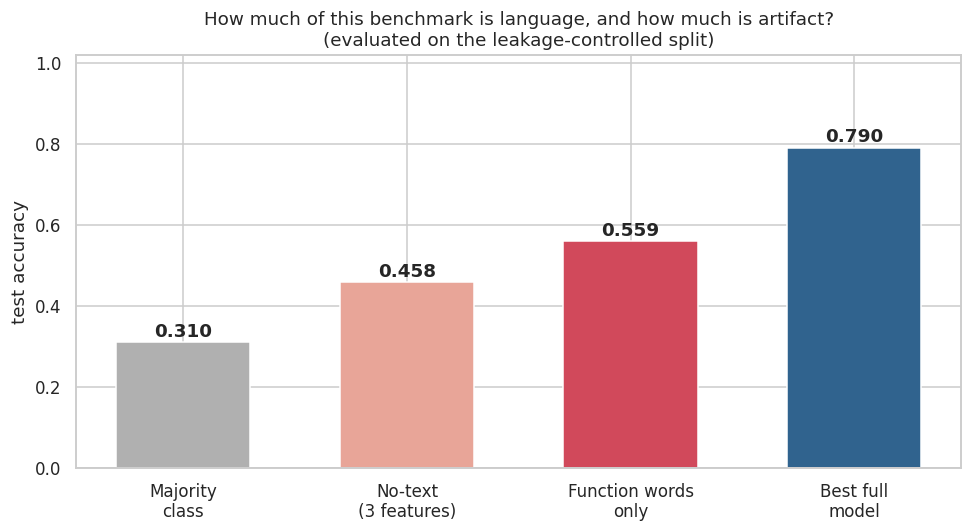

In [ ]:
labels = ["Majority\nclass", "No-text\n(3 features)", "Function words\nonly", "Best full\nmodel"]
vals = [MAJORITY_BASELINE, NOTEXT_ACC, STYLE_ACC, best_acc]
cols = ["#b0b0b0", "#e8a598", "#d1495b", "#30638e"]

fig, ax = plt.subplots(figsize=(9, 5))
b = ax.bar(labels, vals, color=cols, width=0.6)
for r, v in zip(b, vals):
    ax.text(r.get_x() + r.get_width() / 2, v + 0.014, f"{v:.3f}", ha="center", fontweight="bold")
ax.set_ylim(0, 1.02)
ax.set_ylabel("test accuracy")
ax.set_title("How much of this benchmark is language, and how much is artifact?\n"
             "(evaluated on the leakage-controlled split)")
plt.tight_layout()
plt.savefig(OUT / "figures" / "headline_summary.png", bbox_inches="tight")
plt.show()

---
# 14. Error analysis

The twenty most confident wrong predictions from the best model, for manual inspection. Read these and classify each into a failure taxonomy — ambiguous label, genuine comorbidity, sarcasm, quoted third-party speech, or too short to judge — then report the taxonomy as a table in the paper. This costs no compute and is one of the most persuasive sections you can write.

In [ ]:
split_key = "B" if "B" in SPLITS else "A"
sub = RES_DF[RES_DF.split == split_key].sort_values("test_macro_f1", ascending=False)
got = load_proba(sub.iloc[0]["model"], sub.iloc[0]["representation"], split_key)

if got is not None:
    y_true, proba = got
    y_pred = proba.argmax(1)
    conf = proba.max(1)
    wrong = np.where(y_pred != y_true)[0]
    wrong = wrong[np.argsort(-conf[wrong])][:20]

    s = SPLITS[split_key]
    texts = s["frame"]["text"].values[s["test"]]
    ERRORS = pd.DataFrame({
        "confidence": conf[wrong].round(3),
        "true": [CLASS_NAMES[i] for i in y_true[wrong]],
        "predicted": [CLASS_NAMES[i] for i in y_pred[wrong]],
        "text": [texts[i][:220] for i in wrong],
    })
    ERRORS.to_csv(OUT / "tables" / "top_errors.csv", index=False)
    for _, r in ERRORS.head(10).iterrows():
        print(f"[conf {r['confidence']:.3f}] TRUE={r['true']:<22} PRED={r['predicted']:<22}")
        print(f"   {r['text']}\n")

[conf 0.887] TRUE=Anxiety                PRED=Normal                
   Baler question kore rakhce

[conf 0.824] TRUE=Stress                 PRED=Bipolar               
   It sorta works, but I don't like the feeling of being deadheaded. I also don't have a good relationships with doctors considering I was misdiagnosed with bipolar as a teen and given lithium... Had a terrible reaction to 

[conf 0.819] TRUE=Depression             PRED=Suicidal              
   I'm just tired. I want to die. Everything is as fine as its going to get.  I just want to go home and blow my motherfucking brains out.

[conf 0.817] TRUE=Suicidal               PRED=Normal                
   RT @Shen_the_Bird: doctor: i'm afraid he may never wake up from his coma

[conf 0.757] TRUE=Suicidal               PRED=Depression            
   I am just not excited for anything anymore except for drinking and smoking. I kind of feel sad, but numb at the same time. Its just so weird. I keep hoping that I do not wake up w

### Most predictive tokens per class

In [ ]:
split_key = "B" if "B" in SPLITS else "A"
s = SPLITS[split_key]
R = REPS[(split_key, "TF-IDF")]
lr_exp = LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1)
lr_exp.fit(R["train"], s["y_train"])
feat = np.array(REPS[(split_key, "TF-IDF")]["vectorizer"].get_feature_names_out())

print("Inspect these for artifacts: formatting tokens, platform jargon or boilerplate\n"
      "appearing here is direct evidence for RQ2.\n")
for i, c in enumerate(CLASS_NAMES):
    top = feat[np.argsort(-lr_exp.coef_[i])[:15]]
    print(f"{c:<24}: {', '.join(top)}")

Inspect these for artifacts: formatting tokens, platform jargon or boilerplate
appearing here is direct evidence for RQ2.

Anxiety                 : restless, anxiety, worried, nervous, anxious, health anxiety, symptoms, cancer, worry, health, heart, blood, restlessness, pain, about
Bipolar                 : bipolar, manic, meds, episode, mania, hypomanic, lithium, seroquel, ve, bp, lamictal, anyone, diagnosed, depressive, med
Depression              : depression, am, do not, wa, not, depressed, cannot, do, just, feel, life, my depression, ha, not know, it is
Normal                  : ðÿ, wa, yes, oh, eid, twitter, we, yeah, you, quot, met, morning, jyp, laptop, url
Personality disorder    : avpd, don, people, social, my avpd, re, first day, therapy, as, have you, ghosting, pretend, thing, myself to, me
Stress                  : stress, and, stressed, to, https, him, he, ptsd, don, she, tl dr, tl, the, chronic, was
Suicidal                : am, do not, cannot, die, not, suicide, kill, 

---
# 15. Consolidated outputs

Everything needed for the report is written to `outputs/`. Download that folder before the Colab session expires.

In [ ]:
TUNE_DF = pd.DataFrame(TUNING_LOG)
TUNE_DF.to_csv(OUT / "tables" / "tuning_log.csv", index=False)
RES_DF.to_csv(OUT / "tables" / "test_results.csv", index=False)

FINDINGS = {
    "rows_analysed": int(len(work)),
    "classes": int(N_CLASSES),
    "majority_baseline": round(float(MAJORITY_BASELINE), 4),
    "no_text_baseline_acc": round(float(NOTEXT_ACC), 4),
    "function_words_only_acc": round(float(STYLE_ACC), 4),
    "best_model_acc": round(float(best_acc), 4),
    "exact_duplicate_rows": int(D1["dup_rows"]),
    "cross_label_conflict_rows": int(D1["conflict_rows"]),
    "near_duplicate_rows": int(D2["rows_in_multi_groups"]),
    "split_A_test_leakage_rows": int(leak_A["exact_overlap"]),
    "split_B_test_leakage_rows": int(leak_B["exact_overlap"]),
    "tuning_runs_logged": int(len(TUNE_DF)),
    "models_evaluated": int(RES_DF["model"].nunique()),
    "FAST_MODE": bool(FAST_MODE),
}
if "B" in SPLITS:
    piv2 = RES_DF.pivot_table(index="model", columns="split", values="test_accuracy").dropna()
    FINDINGS["mean_leakage_delta"] = round(float((piv2["A"] - piv2["B"]).mean()), 4)

with open(OUT / "findings.json", "w") as fh:
    json.dump(FINDINGS, fh, indent=2)

print(json.dumps(FINDINGS, indent=2))
print("\nfiles written:")
for p in sorted(OUT.rglob("*")):
    if p.is_file():
        print("  ", p)

{
  "rows_analysed": 7984,
  "classes": 7,
  "majority_baseline": 0.3102,
  "no_text_baseline_acc": 0.4579,
  "function_words_only_acc": 0.5591,
  "best_model_acc": 0.7902,
  "exact_duplicate_rows": 1637,
  "cross_label_conflict_rows": 62,
  "near_duplicate_rows": 3590,
  "split_A_test_leakage_rows": 42,
  "split_B_test_leakage_rows": 0,
  "tuning_runs_logged": 120,
  "models_evaluated": 12,
  "FAST_MODE": true,
  "mean_leakage_delta": 0.0081
}

files written:
   outputs/figures/ablation_preprocessing.png
   outputs/figures/class_distribution.png
   outputs/figures/confusion_A.png
   outputs/figures/confusion_B.png
   outputs/figures/headline_summary.png
   outputs/figures/jsd_heatmap.png
   outputs/figures/jsd_vs_confusion.png
   outputs/figures/length_by_class.png
   outputs/figures/notext_baseline.png
   outputs/figures/rnn_training_curves.png
   outputs/figures/rq1_leakage_delta.png
   outputs/figures/wordclouds.png
   outputs/findings.json
   outputs/predictions/BERT-base__BERT__A

In [ ]:
try:
    import shutil
    from google.colab import files as colab_files
    shutil.make_archive("cse440_outputs", "zip", OUT)
    colab_files.download("cse440_outputs.zip")
except Exception as e:
    print("Not in Colab or download unavailable; outputs remain in ./outputs")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>